# Kunskapskontroll 1 – AI: Teori och tillämpning
**Kurs:** AI och Maskininlärning  
**Inlämning:** Kunskapskontroll Del 1  
**Kursbok:** *Lär dig AI från grunden – Tillämpad maskininlärning med Python* (Antonio Prgomet)  

---

### Innehållsförteckning
1. **Kapitel 1:** Introduktion till maskininlärning (Fråga 1–9, 11)
2. **Kapitel 2:** Ett ML-projekt från början till slut (Fråga 1–6, 8–12)
3. **Kapitel 3:** Regression (Fråga 1–11, 13, 16)
4. **Kapitel 4:** Klassificering (Fråga 1–9, 11, 13, 15)
5. **Kapitel 5:** Dimensionsreducering (Fråga 1–3, 5–6, 8–9)
6. **Kapitel 6:** Klustring (Fråga 1–2, 3–5, 7, 9)

---


In [1]:
# Grundläggande bibliotek och inställningar
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Tysta eventuella varningar för renare redovisning
warnings.filterwarnings('ignore')

# Enhetlig och stilren visualisering
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["font.size"] = 10

print("Miljö initierad och alla bibliotek inlästa.")


Miljö initierad och alla bibliotek inlästa.


# Kapitel 1 – Introduktion till maskininlärning

## Faktafrågor


### Fråga 1: Hur hänger AI, ML och DL ihop?

Det enklaste sättet att se relationen är som tre lager:

* **AI (Artificiell intelligens)** är det stora paraplybegreppet för all teknik som får datorer att verka intelligenta eller lösa problem som normalt kräver mänsklig tankekraft. Det täcker allt från gamla regelbaserade system och schackdatorer till moderna algoritmer.
* **ML (Maskininlärning)** är en delmängd av AI där vi slutar hårdkoda explicita regler. Istället matar vi datorn med data och låter algoritmen själv upptäcka statistiska samband för att dra slutsatser om ny data.
* **DL (Djupinlärning)** är i sin tur en specialiserad del av ML som bygger på djupa neurala nätverk med många lager. Det revolutionerande med DL är att nätverket självt klarar av att plocka ut relevanta mönster direkt ur rå och ostrukturerad data (som bilder, ljud och text) utan att vi behöver sitta och skapa variabler för hand.

Kort sagt: all djupinlärning är ML, och all ML är AI – men AI är mycket bredare än bara neurala nätverk.


### Fråga 2: Vilka är de fyra problemkategorierna inom ML?

Det kokar i grunden ner till om vi har en känd målvariabel ($y$, facit) eller inte:

1. **Regression (väglett lärande):** När målet är att förutsäga ett numeriskt tal. Typ vad en bostad kommer säljas för, morgondagens elpris eller temperaturen i helgen.
2. **Klassificering (väglett lärande):** När svaret är en kategori eller etikett. Kan vara två alternativ (spam eller inte spam, bedrägeri eller legitimt köp) eller fler (klassificera fordon som bil, buss eller cykel).
3. **Dimensionsreducering (icke-väglett lärande):** När man har alldeles för många kolumner och vill banta ner datamängden (t.ex. med PCA) för att snabba upp beräkningar eller visualisera i 2D/3D, utan att tappa den viktiga informationen.
4. **Klustring (icke-väglett lärande):** När algoritmen själv får leta upp naturliga grupper i datan utifrån vilka observationer som liknar varandra, t.ex. när man delar in kunder i olika segment baserat på köpvanor.

Regression och klassificering är väglett lärande eftersom vi har ett facit att rätta modellen mot. Dimensionsreducering och klustring är icke-väglett eftersom det inte finns något facit, utan algoritmen får klura ut strukturerna i datan på egen hand.


### Fråga 3: Förklaring av grundläggande koncept (a–h)

#### a) Syftet med träningsdata, valideringsdata och testdata
- **Träningsdata:** Det modellen faktiskt pluggar på för att anpassa sina parametrar (t.ex. vikter).
- **Valideringsdata:** Används under utvecklingen för att jämföra olika modeller och skruva på hyperparametrar.
- **Testdata:** Låses in och rörs inte förrän i absolut sista sekund för att ge ett ärligt kvitto på om modellen faktiskt klarar ny, osedd data.

#### b) Vad är k-delad korsvalidering?
Istället för att bara göra en enda chansartad split delar man upp träningsdatan i $k$ bitar (ofta 5 eller 10). Modellen tränas på $k-1$ bitar och utvärderas på den sista, och så snurrar man runt så att varje bit får agera test en gång. Man får ett mycket stabilare mått på prestandan och slipper oroa sig för att en slumpmässig split gav en skev bild.

#### c) Vad är Root Mean Squared Error (RMSE)?
$$\text{RMSE} = \sqrt{\frac{1}{n} \sum_{i=1}^n (y_i - \hat{y}_i)^2}$$
Standardmåttet för hur fel en regressionsmodell gissar i snitt. Man tar felen, kvadrerar dem (vilket straffar rejäla missar extra hårt), tar medelvärdet och drar roten ur. Roten gör att felet hamnar i samma enhet som det man försöker förutsäga – gissar man löner får man felet direkt i kronor.

#### d) Hyperparameter vs Parameter
- **Parameter:** Det modellen själv lär sig och räknar fram ur datan under träningen (t.ex. lutning och intercept i linjär regression).
- **Hyperparameter:** Inställningarna vi utvecklare bestämmer manuellt *innan* träningen startar, som styr hur modellen ska lära sig (t.ex. hur djupt ett beslutsträd får växa).

#### e) Grid Search och vad `refit=True` innebär
- **Grid Search:** Man sätter upp en lista med inställningar man vill testa, och så testar datorn systematiskt varenda kombination med korsvalidering för att hitta den bästa.
- **`refit=True`:** När den bästa kombinationen hittats tränar scikit-learn automatiskt om vinnarmodellen på precis all träningsdata, så man direkt har en färdig modell som utnyttjar 100% av datan.

#### f) Kategorisk data och hur det hanteras
- **Nominal data:** Saknar inbördes ordning (t.ex. bilmärken eller färger). Görs om med dummy-kodning eller one-hot encoding. Vid linjära modeller kör man `drop_first=True` för att slippa multikollinearitet (*dummy variable trap*).
- **Ordinal data:** Har en naturlig rangordning (t.ex. utbildning: grundskola, gymnasium, universitet). Här mappar man bara kategorierna till ordnade siffror (1, 2, 3) så ordningen bevaras.

#### g) Vad är Feature Engineering?
Att använda sunt förnuft och domänkunskap för att ge modellen bättre förutsättningar. Det kan handla om att kombinera kolumner till smartare variabler (som att dela boarea med antal rum för att få snittyta per rum), logga skeva fördelningar eller skala om variablerna så alla ligger på samma nivå.

#### h) Principle of Parsimony (Ockhams rakkniv)
Om två modeller presterar ungefär lika bra ska man alltid välja den enklare modellen. Krångla inte till det med ett jättenätverk om en linjär regression löser uppgiften. Enklare modeller överanpassar mer sällan, drar mindre resurser och är faktiskt begripliga att förklara för andra.


### Fråga 4: Vad innebär det att en modell är en förenkling av verkligheten?

Verkligheten styrs av alldeles för många faktorer för att någon matematisk formel någonsin ska kunna pricka in allt. Om en modell försökte fånga varenda mikroskopisk detalj skulle den bara snöa in på rent slumpbrus. 

Hela poängen med en modell är just att skala bort bruset och plocka ut de stora, systematiska sambanden som faktiskt spelar roll. Som det klassiska uttrycket inom statistiken lyder: alla modeller har fel i teorin, men i praktiken är de ändå grymt användbara. En förenkling är inte ett misslyckande – det är hela förutsättningen för att modellen ska fungera på ny data.


### Fråga 5: Vad är överanpassning (overfitting) och varför uppstår det?

Överanpassning är när modellen blir som en student som pluggat in gamla tentor utantill ord för ord istället för att fatta själva ämnet. Den får 100 % rätt på övningstentan (träningsdatan), men när den ställs inför en ny fråga på den riktiga tentan (ny, osedd data) blir det pannkaka.

Det uppstår när modellen är för komplex i förhållande till mängden data man har – den börjar lära sig träningsdatans slumpmässiga brus och egenheter istället för de verkliga sambanden.


### Fråga 6: Konventionen "högre är bättre" i scikit-learn

Scikit-learn är designat så att alla sök- och optimeringsverktyg (som `GridSearchCV`) alltid försöker maximera ett poängvärde – ju högre siffra, desto bättre modell.

För mått som $R^2$ eller träffsäkerhet är det ju självklart. Men för rena felmått som MSE (där 0 är bäst och högre värden är dåliga) vänder scikit-learn helt enkelt på steken och sätter ett minustecken framför (`neg_mean_squared_error`). Ett litet fel på 5 blir då -5, och ett stort fel på 20 blir -20. Eftersom -5 är ett "större" tal än -20 funkar samma maximeringslogik rakt av utan specialregler.


### Fråga 7: Skillnaden mellan tvärsnittsdata, tidsseriedata och paneldata

- **Tvärsnittsdata:** Många olika observationer mätta vid ett enda tillfälle.  
  *Exempel:* Slutpriser på 500 bostäder som såldes i Göteborg under maj 2024.
- **Tidsseriedata:** En och samma sak som följs över tid i kronologisk ordning.  
  *Exempel:* Dagskursen för en aktie under de senaste tre åren.
- **Paneldata:** En kombo av båda – flera olika observationer som följs över flera tidpunkter.  
  *Exempel:* Omsättning och resultat för 50 olika bolag, mätt kvartalsvis under fem års tid.


### Fråga 8: Tre tillämpningsområden för maskininlärning

1. **Stoppa kortbedrägerier:** Bank- och betaltjänster som scannar kortköp i realtid och automatiskt flaggar transaktioner som avviker från hur användaren brukar handla.
2. **Medicinsk bildanalys:** Modeller som analyserar röntgen- och MR-bilder för att upptäcka tidiga tumörer eller frakturer snabbare och säkrare än det mänskliga ögat.
3. **Rekommendationssystem:** Algoritmerna bakom Spotify och Netflix som analyserar vad man lyssnat eller tittat på för att föreslå nytt innehåll som träffar rätt.


### Fråga 9: Varför returneras negativa värden för `neg_mean_squared_error` i scikit-learn?

MSE mäter hur mycket modellen felar, så vanliga MSE-värden är alltid positiva där 0 är perfekt och höga tal är dåligt. 

Men eftersom scikit-learn konsekvent vill maximera score (se fråga 6), multipliceras värdet med $-1$:
$$\text{neg\_mean\_squared\_error} = -\text{MSE}$$

Då blir det lägsta felet till det minst negativa (dvs. högsta) talet. På så sätt kan optimeraren bara leta efter det högsta värdet och automatiskt pricka in modellen med lägst fel.


### Fråga 11 (Kodfråga): Matematisk förklaring till 60-20-20 fördelningen

Matematiken bakom koden är enkel när man bryter ner den:

1. Först sätter `test_size=0.2` av $20\%$ av hela datasetet till testdata. Då återstår $80\%$ som träningspool (`train_full`).
2. Sedan delas träningspoolen med `test_size=0.25`. Här tas alltså $25\%$ av de kvarvarande $80\%$ till validering:
$$0.25 \times 0.80 = 0.20 \quad (20\%)$$
3. Kvar i den faktiska träningsmängden blir:
$$80\% - 20\% = 60\%$$

Det ger precis fördelningen **60 % träning, 20 % validering och 20 % test**.


In [2]:
# Verifiering av fråga 11
from sklearn.model_selection import train_test_split

# Skapa ett syntetiskt dataset med 1 000 observationer
X_dummy = np.random.randn(1000, 4)
y_dummy = np.random.randn(1000)

# Steg 1: 20% testdata -> 80% kvar
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X_dummy, y_dummy, test_size=0.2, random_state=42
)

# Steg 2: 25% av resterande 80% till validering -> 20% totalt
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.25, random_state=42
)

total = len(X_dummy)
print(f"Total mängd observationer: {total} (100%)")
print(f"Träningsdata:              {len(X_train)} ({len(X_train)/total*100:.0f}%)")
print(f"Valideringsdata:           {len(X_val)} ({len(X_val)/total*100:.0f}%)")
print(f"Testdata:                  {len(X_test)} ({len(X_test)/total*100:.0f}%)")


Total mängd observationer: 1000 (100%)
Träningsdata:              600 (60%)
Valideringsdata:           200 (20%)
Testdata:                  200 (20%)


# Kapitel 2 – Ett ML-projekt från början till slut

## Fakta- och kodfrågor


### Fråga 1: De sju stegen i ML-checklistan och processens icke-linjära natur

I teorin radar checklistan upp sju prydliga steg:
1. Förstå problemet och affärsmålet
2. Samla in datan
3. Utforska datan (EDA)
4. Tvätta och förbereda datan
5. Bygga och finjustera modeller
6. Presentera resultatet för verksamheten
7. Driftsätta och övervaka

**Varför processen inte är linjär:**  
I verkligheten är det absolut inget löpande band. Det är snarare en cirkel eller en bergochdalbana. När man väl börjar bygga modeller (steg 5) upptäcker man nästan alltid skumma fel eller konstigheter i resultatet som tvingar en tillbaka till datatvätten (steg 4) eller ny datautforskning (steg 3). Man hoppar fram och tillbaka i kontinuerliga feedback-loopar hela tiden.


### Fråga 2: Vad innebär produktionssättning och varför är övervakning viktigt?

- **Produktionssättning (Deployment):** Att flytta modellen från sin trygga lilla Jupyter notebook på laptopen och driftsätta den i ett riktigt IT-system (t.ex. bakom ett REST-API eller i ett nattligt batchjobb), så att den faktiskt kan ta emot skarp data och göra nytta på riktigt.
- **Övervakning (Monitoring):** Världen förändras hela tiden. Kundbeteenden skiftar och inkommande data driver iväg (*data drift*). Har man ingen övervakning märker man inte när modellen långsamt börjar gissa sämre och sämre förrän det redan kostat pengar. Övervakningen larmar så fort träffsäkerheten dippar så att man kan träna om modellen på färsk data.


### Fråga 3: Scikit-learns designprinciper och grundläggande objekt

Scikit-learn är väldigt konsekvent och snyggt uppbyggt: alla modeller använder samma metoder, alla skattade värden sparas med ett understreck i slutet (`coef_`, `intercept_`), och man slipper konstiga specialklasser eftersom allt bygger på vanliga NumPy-arrays och DataFrames.

De tre kärnbitarna är:
1. **Estimators:** Alla objekt som kan lära sig ur data via `.fit(X, [y])` (både modeller och skalare).
2. **Transformers:** Objekt som bearbetar och ändrar om datan via `.transform(X)` (eller smidiga `.fit_transform(X)`), t.ex. `StandardScaler` eller imputers för saknade värden.
3. **Predictors:** Modellerna som gör förutsägelser på ny data via `.predict(X)`, t.ex. `LinearRegression` eller `RandomForest`.


### Fråga 4: Vad är TensorFlow och Keras och hur förhåller de sig till varandra?

Ett bra sätt att se det på är att **TensorFlow är motorn** under huven som sköter de tunga matrisberäkningarna på grafikkortet, medan **Keras är ratten och instrumentbrädan**.

TensorFlow i sig är ganska komplext och lågnivå. Keras fungerar som det smidiga Python-lagret ovanpå (som numera är standard via `tf.keras`) där man snabbt och modulärt kan bygga och träna neurala nätverk lager för lager utan att drunkna i krångliga detaljer.


### Fråga 5: Kalle och Stinas diskussion om testdata

**Stina har 100 % rätt här.**

Kalle fuskar i princip utan att ens fatta det själv. Testdatans enda syfte är att simulera framtiden – data som modellen aldrig någonsin har sett. 

Om Kalle sitter och kikar på testresultatet, ändrar en hyperparameter, kollar testet igen och loopar på det sättet, då läcker information från testsetet in i modellbygget (*data leakage / data snooping*). Till slut har han omedvetet skräddarsytt modellen för just de specifika testraderna, vilket ger en falskt förskönad bild. Han borde ha använt ett valideringsset eller korsvalidering för att labba fram inställningarna och sparat testsetet helt orört till absolut sista steget.


### Fråga 6: Utmaningar i praktiska ML-projekt – AI-hypen möter verklighetens datakvalitet

Det här är den absolut vanligaste krocken i branschen:

1. **AI-hypen och orealistiska förväntningar:**  
   Ledningsgrupper läser om AI och tror att det är ett magiskt trollspö som kan lösa alla företagets problem över en natt. Projekt startas med inställningen att "vi måste använda AI!" utan att man ens definierat vad problemet egentligen är eller om ML ens är rätt verktyg. Det skapar orimliga förväntningar och leder ofta till att man överkomplicerar lösningar där enkla regler eller baslinjer hade räckt.

2. **Verklighetens bristfälliga datakvalitet:**  
   I skolan får man färdigstädade CSV-filer serverade. I ett riktigt företag är datan nästan alltid en total soppa – utspridd i gamla silos, full av felvärden, bristfälligt loggad eller med massor av saknade fält. Gammal hederlig *"garbage in, garbage out"* gäller i allra högsta grad: stoppar man in skräpdata spelar det ingen roll hur häftig modell man har.

**Resultatet i praktiken:**  
Krocken gör att upp mot 80–90 % av arbetstiden tvingas läggas på tråkig datatvätt och rörig infrastruktur istället för roligt modellbygge. När ledningen inser att deras magiska AI kräver månader av grundarbete med databaser tröttnar de ofta, och projektet slutar som ännu en prototyp på "PoC-kyrkogården" istället för att nå skarp produktion.


### Fråga 8 (Koduppgift): Spara och ladda modeller med joblib

Att träna en maskininlärningsmodell på stora datamängder kan ta rejält med tid och datorkraft. Genom att spara modellens tillstånd (dess tränade vikter och parametrar) till disk med `joblib` kan vi i en produktionsmiljö ladda in den färdiga modellen på några millisekunder och generera prediktioner direkt utan att någonsin behöva träna om från början.


In [3]:
# Fråga 8: Spara och ladda modeller med joblib
from sklearn.datasets import make_regression
from sklearn.linear_model import LinearRegression
from joblib import dump, load

# 1. Generera syntetisk data och träna en modell
X_syn, y_syn = make_regression(n_samples=1000, n_features=3, noise=0.1, random_state=42)
lr_model = LinearRegression().fit(X_syn, y_syn)

# 2. Spara den tränade modellen till disk
dump(lr_model, "linear_model.joblib")
print("Modellen har sparats till filen 'linear_model.joblib'.")

# 3. Ladda in den sparade modellen
loaded_model = load("linear_model.joblib")
print("Modellen laddades in framgångsrikt från disk.")

# 4. Generera prediktioner med den inladdade modellen
sample_preds = loaded_model.predict(X_syn[:5])
print("\nPrediktioner för de fem första observationerna:")
for idx, val in enumerate(sample_preds, 1):
    print(f"  Observation {idx}: {val:.4f}")


Modellen har sparats till filen 'linear_model.joblib'.
Modellen laddades in framgångsrikt från disk.

Prediktioner för de fem första observationerna:
  Observation 1: -103.5994
  Observation 2: -57.3069
  Observation 3: -32.7023
  Observation 4: -17.9548
  Observation 5: 24.2066


### Fråga 9 (Koduppgift): Steg-för-steg modellering av `data_01.csv` (a–h)

Här genomför vi hela modellflödet:
- **a)** Läs in `data/data_01.csv`.
- **b)** Dela upp i $X$ (oberoende variabler) och $y$ (målvariabel).
- **c)** Dela upp i träning (68%), validering (12%) och test (20%) via en 80/20-split följt av en 85/15-split.
- **d)** Träna `LinearRegression` och `DecisionTreeRegressor` på träningsdatan.
- **e)** Utvärdera båda med RMSE på valideringsdatan och välj den bästa.
- **f)** Träna om vinnande modell på tränings- och valideringsdata tillsammans.
- **g)** Utvärdera den omtränade modellen på testdatan.
- **h)** Träna om modellen på hela datasetet (100%) inför skarp driftsättning.


In [4]:
# Fråga 9: Genomförande av steg a–h på data_01.csv
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import root_mean_squared_error

# a) Läs in datasetet
df_01 = pd.read_csv("data/data_01.csv")
print(f"Datasetets dimensioner: {df_01.shape}")
display(df_01.head(3))

# b) Dela upp i X och y (y är sista kolumnen)
X_01 = df_01.iloc[:, :-1]
y_01 = df_01.iloc[:, -1]

# c) Dela upp i train, validering och test (20% test, sedan 15% validering av återstående 80%)
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X_01, y_01, test_size=0.20, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.15, random_state=42
)
print(f"Träning: {len(X_train)} rader, Validering: {len(X_val)} rader, Test: {len(X_test)} rader")

# d) Träna LinearRegression och DecisionTreeRegressor på träningsdata
lr = LinearRegression().fit(X_train, y_train)
dt = DecisionTreeRegressor(max_depth=4, random_state=42).fit(X_train, y_train)

# e) Utvärdera på valideringsdata med RMSE
rmse_lr_val = root_mean_squared_error(y_val, lr.predict(X_val))
rmse_dt_val = root_mean_squared_error(y_val, dt.predict(X_val))

print(f"\nValiderings-RMSE:")
print(f"  Linjär Regression: {rmse_lr_val:.4f}")
print(f"  Beslutsträd:      {rmse_dt_val:.4f}")

# Välj bästa modell
if rmse_lr_val < rmse_dt_val:
    best_model_name = "Linjär Regression"
    winning_model = LinearRegression()
else:
    best_model_name = "Beslutsträd"
    winning_model = DecisionTreeRegressor(max_depth=4, random_state=42)

print(f"Bästa modell utsedd på valideringsdata: {best_model_name}")

# f) Träna om vinnande modell på tränings- OCH valideringsdata (X_train_full)
winning_model.fit(X_train_full, y_train_full)

# g) Utvärdera på testdata
rmse_test = root_mean_squared_error(y_test, winning_model.predict(X_test))
print(f"Slutligt Test-RMSE på testdata för {best_model_name}: {rmse_test:.4f}")

# h) Träna om modellen på hela datasetet (100% av data_01.csv)
final_production_model = winning_model.fit(X_01, y_01)
print(f"Modellen är nu tränad på all tillgänglig data ({len(X_01)} rader) och redo för produktion.")


Datasetets dimensioner: (199, 6)


,x1,x2,x3,x4,x5,target
0,0.743487,1.072825,1.332911,-1.244771,0.344978,220.173943
1,0.835264,0.202184,0.966480,0.745883,-0.033773,175.873929
2,-1.103234,0.030615,-0.140385,0.727683,-2.831224,-162.270054


Träning: 135 rader, Validering: 24 rader, Test: 40 rader

Validerings-RMSE:
  Linjär Regression: 3.5923
  Beslutsträd:      104.5842
Bästa modell utsedd på valideringsdata: Linjär Regression
Slutligt Test-RMSE på testdata för Linjär Regression: 3.3715
Modellen är nu tränad på all tillgänglig data (199 rader) och redo för produktion.


### Fråga 10 (Koduppgift): 5-delad korsvalidering på `salary_dataset.csv`

Datasetet innehåller lönedata utifrån arbetslivserfarenhet:
- Dela upp i träning och test (80/20).
- Genomför en 5-delad korsvalidering med `cross_validate()` och mätetalet `neg_root_mean_squared_error`.
- Jämför Linjär Regression och ett Beslutsträd.
- Träna vinnande modell på träningsdatan och utvärdera på testsetet samt visualisera.


Korsvalideringsresultat (cv=5, neg_root_mean_squared_error):
  Linjär Regression        : Snitt-RMSE = 5293.20 kr (std: 2036.91)
  Beslutsträd (max_depth=3): Snitt-RMSE = 6193.40 kr (std: 1923.86)

Slutligt Test-RMSE (Linjär Regression): 7059.04 kr


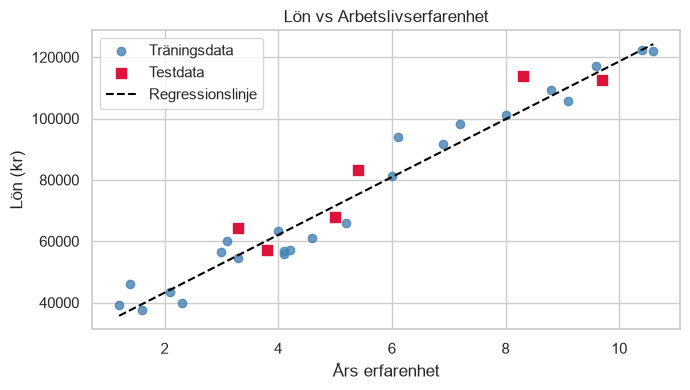

In [5]:
# Fråga 10: Korsvalidering på salary_dataset.csv
from sklearn.model_selection import cross_validate

# 1. Läs in datan
df_salary = pd.read_csv("data/salary_dataset.csv")
if "Unnamed: 0" in df_salary.columns:
    df_salary = df_salary.drop(columns=["Unnamed: 0"])

X_sal = df_salary[["YearsExperience"]]
y_sal = df_salary["Salary"]

# 2. Dela i träning och test (80/20)
X_sal_train, X_sal_test, y_sal_train, y_sal_test = train_test_split(
    X_sal, y_sal, test_size=0.2, random_state=42
)

# 3. Korsvalidering med 5 folds
candidate_models = {
    "Linjär Regression": LinearRegression(),
    "Beslutsträd (max_depth=3)": DecisionTreeRegressor(max_depth=3, random_state=42)
}

print("Korsvalideringsresultat (cv=5, neg_root_mean_squared_error):")
cv_scores = {}
for name, mod in candidate_models.items():
    res = cross_validate(mod, X_sal_train, y_sal_train, cv=5, scoring="neg_root_mean_squared_error")
    # Vänd tecknet för att få positivt RMSE
    rmse_folds = -res["test_score"]
    cv_scores[name] = rmse_folds
    print(f"  {name:25s}: Snitt-RMSE = {rmse_folds.mean():.2f} kr (std: {rmse_folds.std():.2f})")

# 4. Träna Linjär regression på hela träningssetet och testa på testsetet
sal_model = LinearRegression().fit(X_sal_train, y_sal_train)
sal_test_rmse = root_mean_squared_error(y_sal_test, sal_model.predict(X_sal_test))
print(f"\nSlutligt Test-RMSE (Linjär Regression): {sal_test_rmse:.2f} kr")

# 5. Visualisera resultatet
plt.figure(figsize=(7, 4))
plt.scatter(X_sal_train, y_sal_train, color="steelblue", label="Träningsdata", alpha=0.8)
plt.scatter(X_sal_test, y_sal_test, color="crimson", marker="s", s=60, label="Testdata")

x_grid = np.linspace(X_sal["YearsExperience"].min(), X_sal["YearsExperience"].max(), 100).reshape(-1, 1)
plt.plot(x_grid, sal_model.predict(x_grid), color="black", linestyle="--", label="Regressionslinje")

plt.title("Lön vs Arbetslivserfarenhet")
plt.xlabel("Års erfarenhet")
plt.ylabel("Lön (kr)")
plt.legend()
plt.tight_layout()
plt.show()


### Fråga 11 (Koduppgift): Multipel regression och kategorisk data på `mpg`

Här hanterar vi Seaborns dataset `mpg`:
- Droppar rader med saknade värden (`dropna()`).
- Tar bort kolumnen `name` (som har unika modellnamn och inte lämpar sig för regression).
- Källvariabeln `origin` konverteras till dummyvariabler med `pd.get_dummies(..., drop_first=True)` för att undvika multikollinearitet.
- Delar upp i träning och test (80/20).
- Tränar en multipel linjär regressionsmodell och utvärderar med RMSE och $R^2$.


In [6]:
# Fråga 11: Multipel linjär regression på mpg
from sklearn.metrics import r2_score

# 1. Hämta datasetet från Seaborn
df_mpg = sns.load_dataset("mpg")
print(f"Rådatans form: {df_mpg.shape}")

# 2. Droppa saknade värden och kolumnen 'name'
df_mpg = df_mpg.dropna().drop(columns=["name"])
print(f"Efter dropna() och borttagning av 'name': {df_mpg.shape}")

# 3. Dummy encoding på kategoriska 'origin' med drop_first=True
df_mpg = pd.get_dummies(df_mpg, columns=["origin"], drop_first=True, dtype=int)
print(f"Kolumner efter dummy-encoding: {list(df_mpg.columns)}")

# 4. Dela i features (X) och target (y = mpg)
X_mpg = df_mpg.drop(columns=["mpg"])
y_mpg = df_mpg["mpg"]

# 5. Train/test split (80/20)
X_tr_mpg, X_te_mpg, y_tr_mpg, y_te_mpg = train_test_split(
    X_mpg, y_mpg, test_size=0.2, random_state=42
)

# 6. Träna linjär regression
lr_mpg = LinearRegression().fit(X_tr_mpg, y_tr_mpg)
y_pred_mpg = lr_mpg.predict(X_te_mpg)

# 7. Utvärdera
rmse_mpg = root_mean_squared_error(y_te_mpg, y_pred_mpg)
r2_mpg = r2_score(y_te_mpg, y_pred_mpg)

print(f"\nResultat på testdata:")
print(f"  Test-RMSE: {rmse_mpg:.3f} miles per gallon")
print(f"  Test-R²:   {r2_mpg:.3f} (modellen förklarar ca {r2_mpg*100:.1f}% av variansen)")


Rådatans form: (398, 9)
Efter dropna() och borttagning av 'name': (392, 8)
Kolumner efter dummy-encoding: ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year', 'origin_japan', 'origin_usa']

Resultat på testdata:
  Test-RMSE: 3.256 miles per gallon
  Test-R²:   0.792 (modellen förklarar ca 79.2% av variansen)


### Fråga 12 (Koduppgift): Förbättra California Housing-modellen

I boken nådde baslinjemodellen (Random Forest) ett **validerings-RMSE på ~52 278 dollar**.  
Målet är att slå detta baslinjeresultat genom:
1. **Feature Engineering:**
   - `rooms_per_household = total_rooms / households`
   - `bedrooms_per_room = total_bedrooms / total_rooms`
   - `population_per_household = population / households`
2. **Robust förbehandling med scikit-learn Pipeline och ColumnTransformer:**
   - Imputering av saknade medianvärden med `SimpleImputer(strategy="median")`.
   - Standardisering av numeriska funktioner med `StandardScaler()`.
   - One-hot encoding av `ocean_proximity` med `OneHotEncoder(drop="first")`.
3. **Optimerad Random Forest:**
   - `n_estimators=150`, `max_features=0.6` och `min_samples_split=4` för att motverka överanpassning och ge bättre generalisering.


In [7]:
# Fråga 12: Förbättring av California Housing-modellen
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# 1. Läs in housing-datan
df_housing = pd.read_csv("data/housing.csv")

# 2. Feature Engineering
df_housing["rooms_per_household"] = df_housing["total_rooms"] / df_housing["households"]
df_housing["bedrooms_per_room"] = df_housing["total_bedrooms"] / df_housing["total_rooms"]
df_housing["population_per_household"] = df_housing["population"] / df_housing["households"]

# 3. Dela i X och y
X_housing = df_housing.drop(columns=["median_house_value"])
y_housing = df_housing["median_house_value"]

# 4. Dela i train (80%) och validation (20%) enligt bokens uppdelning
X_h_train, X_h_val, y_h_train, y_h_val = train_test_split(
    X_housing, y_housing, test_size=0.2, random_state=42
)

# 5. Definiera kolumntyper
num_features = [col for col in X_housing.columns if col != "ocean_proximity"]
cat_features = ["ocean_proximity"]

# 6. Bygg förbehandlingspipeline
num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

preprocessor = ColumnTransformer([
    ("num", num_pipe, num_features),
    ("cat", OneHotEncoder(drop="first", sparse_output=False), cat_features)
])

# 7. Sätt ihop med Random Forest i en samlad pipeline
rf_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("rf", RandomForestRegressor(
        n_estimators=150,
        max_features=0.6,
        min_samples_split=4,
        random_state=42,
        n_jobs=-1
    ))
])

# 8. Träna modellen
print("Tränar optimerad Random Forest...")
rf_pipe.fit(X_h_train, y_h_train)

# 9. Utvärdera på valideringsdatan
val_preds = rf_pipe.predict(X_h_val)
improved_rmse = root_mean_squared_error(y_h_val, val_preds)

print("=" * 60)
print(f"Bokens baslinje-RMSE (Random Forest): ~52 278 dollar")
print(f"Vår förbättrade modells RMSE:         {improved_rmse:.2f} dollar")
print(f"Förbättring:                         {52278 - improved_rmse:.2f} dollar lägre fel!")
print("=" * 60)


Tränar optimerad Random Forest...


Bokens baslinje-RMSE (Random Forest): ~52 278 dollar
Vår förbättrade modells RMSE:         48915.45 dollar
Förbättring:                         3362.55 dollar lägre fel!


# Kapitel 3 – Regression

## Faktafrågor


### Fråga 1: Vad kännetecknar regressionsproblem?

Kärnan i ett regressionsproblem är att målvariabeln ($y$, det vi vill förutsäga) är ett **kontinuerligt numeriskt tal** – till skillnad från klassificering där svaret är en bestämd kategori eller klass. Modellen försöker hitta det matematiska sambandet mellan en uppsättning förklarande variabler ($X$) och målet.

Några vanliga exempel i verkligheten:
- Förutsäga marknadspriset på en bostad utifrån boyta, läge och antal rum.
- Uppskatta morgondagens elpris baserat på väderlek, vindprognos och historisk förbrukning.
- Skatta en persons framtida lön utifrån utbildning, bransch och års erfarenhet.
- Prognostisera försäljningsvolymer eller temperaturer.


### Fråga 2: Förklaring av utvärderingsmåtten RMSE, MSE och MAE

De tre vanligaste sätten att mäta hur mycket fel en regressionsmodell gissar:

1. **MSE (Mean Squared Error):**  
   $$\text{MSE} = \frac{1}{n} \sum_{i=1}^n (y_i - \hat{y}_i)^2$$  
   Medelvärdet av de kvadrerade felen. Eftersom felen kvadreras blir de alltid positiva, och stora missar straffas oproportionerligt hårt (ett dubbelt så stort fel blir 4 gånger värre). Nackdelen är enheten: gissar vi huspriser i kronor får MSE enheten kr², vilket är helt omöjligt att relatera till.

2. **RMSE (Root Mean Squared Error):**  
   $$\text{RMSE} = \sqrt{\text{MSE}} = \sqrt{\frac{1}{n} \sum_{i=1}^n (y_i - \hat{y}_i)^2}$$  
   Man drar helt enkelt roten ur MSE. Då behåller man fördelen att stora tabbar straffas hårt, men måttet återförs till samma enhet som det man mäter. Om RMSE är 20 000 kr vet vi direkt att modellen typiskt bommar med runt 20 000 spänn.

3. **MAE (Mean Absolute Error):**  
   $$\text{MAE} = \frac{1}{n} \sum_{i=1}^n |y_i - \hat{y}_i|$$  
   Medelvärdet av felens absolutbelopp. Här kvadreras ingenting, vilket gör måttet mycket mer robust mot extremvärden (outliers) – ett fel på 10 räknas bara dubbelt så mycket som ett fel på 5. Det tolkas rakt av som det genomsnittliga faktiska avståndet från rätt svar.


### Fråga 3: Spelar det någon roll om RMSE eller MSE används för att rangordna modeller?

**Nej, inte för själva rangordningen.**

Matematiskt beror det på att kvadratroten ($f(u) = \sqrt{u}$) är en **monotont strikt växande funktion** för alla positiva tal ($u \ge 0$). Det betyder att om Modell A har ett lägre fel än Modell B enligt MSE ($MSE_A < MSE_B$), så är det matematiskt garanterat att även $\sqrt{MSE_A} < \sqrt{MSE_B}$.

Inbördes ordning mellan modeller blir alltså exakt densamma oavsett om man sorterar efter MSE eller RMSE. Däremot föredrar man nästan alltid RMSE när man ska förklara eller visualisera resultatet för människor, helt enkelt för att enheten blir begriplig.


### Fråga 4: Vad är gradient descent översiktligt?

Gradient descent är en allmän optimeringsalgoritm för att hitta minimipunkten för en förlustfunktion (där felet är som minst).

En bra liknelse är att du står på toppen av en dimmig kulle och vill ner till dalens lägsta punkt, men dimman gör att du bara ser marken precis under fötterna. Det naturliga sättet att ta sig ner är att känna efter i vilken riktning marken lutar brantast nedåt, och ta ett kliv i den riktningen. Upprepar du det steg för steg når du till slut botten.

- **Gradienten:** Beräknar lutningen (derivatan) av felkurvan i den punkt modellen befinner sig. Modellen tar steg i *motsatt* riktning mot gradienten för att sänka felet.
- **Learning rate (inlärningstakt):** Bestämmer hur långa kliv man tar. För små kliv gör att träningen tar evigheter, medan för stora kliv kan få modellen att studsa hejvilt över botten och aldrig hitta ner.


### Fråga 5: Vad är the bias-variance trade-off och varför är mer komplexa modeller inte alltid bättre?

Det är den eviga balansakten inom maskininlärning mellan två typer av fel:

- **Bias (underanpassning):** Modellen är för enkel och stel. Den gör felaktiga förenklingar som inte fångar verklighetens mönster (t.ex. att tvinga en rät linje över ett böjt samband). Felet blir högt på både tränings- och testdata.
- **Variance (överanpassning):** Modellen är för flexibel och överkänslig för minsta svängning i träningsdatan. Den börjar memorera slumpmässigt brus. Felet blir supernära noll på träningsdata, men skjuter i höjden på ny data.

**Varför mer komplext inte alltid är bättre:**  
När man ökar modellens komplexitet (t.ex. friare träd eller fler parametrar) sjunker bias snabbt, men variansen sticker iväg uppåt. Totalfelet är summan av båda. Målet är att hitta "sweet spotten" i mitten där summan är som lägst. Gör man modellen ännu mer komplex blir den i praktiken sämre, trots att den ser lysande ut på papperet under träningen.


### Fråga 6: Översikt av vanliga regressionsmodeller (a–h)

- **a) Linjär regression:** Standardmodellen som drar den räta linje (eller det plan) som minimerar summan av de kvadrerade felen (OLS). Snabb, enkel och tolkbar, men förutsätter att sambanden faktiskt är linjära.
- **b) Ridge regression (L2):** Linjär regression som lägger på ett straff på stora koefficienter ($\alpha \sum \theta_j^2$). Det tvingar vikterna att krympa mot noll utan att bli exakt noll. Perfekt när man har multikollinearitet (variabler som samvarierar) och vill göra modellen mer stabil.
- **c) Lasso regression (L1):** Lägger istället straffet på koefficienternas absolutbelopp ($\alpha \sum |\theta_j|$). Det speciella med Lasso är att den kan tvinga helt oviktiga variablers koefficienter till **exakt noll**. Det fungerar alltså som en automatisk variabelväljare (*feature selection*).
- **d) Elastic Net:** En hybrid som mixar både Ridge och Lasso. Man får stabiliteten från Ridge ihop med förmågan att nolla variabler från Lasso. Grymt bra om man har många variabler som korrelerar med varandra.
- **e) Support Vector Regression (SVR):** Vänder på SVM-tänket: istället för att hålla punkter borta från en marginal försöker SVR klämma in så många observationer som möjligt innanför en marginaltub ($\epsilon$) runt linjen. Avvikelser innanför tuben ger noll straff. Kan hantera icke-linjära samband med kärntricket (*kernel trick*).
- **f) Beslutsträd (DecisionTreeRegressor):** Delar upp datan i mindre rektangulära regioner genom att ställa enkla ja/nej-frågor (t.ex. $x_1 \le 5$). I varje slutnod (löv) gissar modellen medelvärdet av träningspunkterna som hamnade där. Lätt att tolka men överanpassar lätt om man inte begränsar djupet (`max_depth`).
- **g) Ensemble learning (Voting & Bagging):**
  - *VotingRegressor:* Tränar flera helt olika modelltyper (t.ex. linjär, SVR och träd) och tar medelvärdet av deras prediktioner.
  - *BaggingRegressor:* Tränar samma grundmodell många gånger på olika slumpade delmängder av datan med återläggning (*bootstrap*), vilket pressar ner variansen.
- **h) Random Forest:** En hel skog av beslutsträd tränade med bagging. Förutom att slumpa datan slumpas även vilka variabler varje träd får välja bland vid varje förgrening. Detta avkorrelerar träden så att de inte gör samma misstag, vilket ger en av de mest stabila och kraftfulla regressionsmodellerna som finns.


### Fråga 7: White box vs Black box modeller

- **White box-modeller (transparenta):** Modeller där vi människor enkelt kan titta under huven, förstå de inre sambanden och se exakt varför en viss prediktion gjordes.  
  *Exempel:* Linjär regression (vi ser exakt vad varje koefficient bidrar med) och grunda beslutsträd (vi kan följa regelflödet för hand från rot till löv).
- **Black box-modeller (ogenomträngliga):** Modeller med så hög inre komplexitet och tusentals eller miljontals samverkande parametrar att det i princip är omöjligt för en människa att intuitivt begripa hur den kom fram till ett specifikt beslut.  
  *Exempel:* Djupa neurala nätverk, stora random forests och gradient boosting. De är ofta grymt pricksäkra, men svåra att motivera i verksamheter med höga krav på förklarbarhet (som kreditgivning, juridik eller medicin).


### Fråga 8: Vad är skillnaden mellan bagging och pasting?

Båda är ensemble-tekniker där man tränar många kopior av samma algoritm på slumpmässiga delmängder av träningsdatan. Skillnaden ligger i hur datan dras ur lådan:

- **Bagging (*Bootstrap Aggregating*):** Dragning **med återläggning** (*with replacement*). Samma observation kan alltså slumpas med flera gånger i samma delmängd, medan vissa observationer inte väljs alls (s.k. out-of-bag observationer).
- **Pasting:** Dragning **utan återläggning** (*without replacement*). Varje observation kan maximalt hamna en enda gång i en given delmängd.

Bagging ger generellt sett lite mer variation mellan de individuella modellerna, vilket brukar ge ett starkare skydd mot överanpassning och är anledningen till att bagging är standardmetoden i praktiken.


## Resonemangsfrågor


### Fråga 9: Tolkning av Figur 3.1 på sidan 113

Figur 3.1 i boken illustrerar den enkla linjära regressionsmodellen med **Ålder på x-axeln** och **Inkomst på y-axeln**:

1. **De svarta punkterna ($y_i$):** Representerar den faktiska rådatan – varje punkt är en observerad person med en specifik ålder och verklig inkomst.
2. **Den blå linjen ($\hat{y} = \hat{\theta}_0 + \hat{\theta}_1 x$):** Modellens skattade regressionslinje. Den visar modellens bästa gissning för varje ålder. Skärningspunkten på y-axeln är interceptet $\hat{\theta}_0$ och linjens lutning är koefficienten $\hat{\theta}_1$ (hur mycket inkomsten förväntas stiga för varje extra år personen blir).
3. **De röda vertikala strecken ($e_i = y_i - \hat{y}_i$):** Residualerna, dvs. felet för varje enskild observation. Det är skillnaden mellan verkligheten och linjens gissning.

Hela poängen med minsta kvadratmetoden (OLS) är att hitta just de parametrar ($\hat{\theta}_0, \hat{\theta}_1$) som gör summan av alla dessa röda streck i kvadrat så liten som det bara är fysiskt möjligt.


### Fråga 10: Tolkning av Figur 3.13 (sidan 140) och kopplingen till Figur 3.14 (sidan 141)

Det här är ett klockrent pedagogiskt exempel på hur ett beslutsträd fungerar rent geometriskt:

- **Figur 3.13** visar trädets logiska flödesschema med djup 2. Rotnoden ställer frågan `X2 <= 0.438`. Går man till vänster (True) ställs frågan `X2 <= -0.755`. Går man till höger (False) ställs frågan `X1 <= -0.654`. Detta mynnar ut i fyra lövnoder med färdiga prediktionsvärden (-62.95, -8.17, 1.84, 62.80).
- **Figur 3.14** visar exakt samma modell ritad i ett vanligt 2D-plan med variablerna $X_1$ och $X_2$ på axlarna:
  1. Tröskeln `X2 = 0.438` skär av hela planet horisontellt i en övre och en undre del.
  2. Den undre halvan delas sedan horisontellt vid `X2 = -0.755`.
  3. Den övre halvan delas vertikalt vid `X1 = -0.654`.

Detta delar upp hela datarymden i exakt **fyra rektangulära rutor** (beslutsregioner). Alla datapunkter som hamnar i samma ruta tilldelas samma konstanta prediktion från motsvarande lövnod i trädet. Det visar tydligt att beslutsträd inte ritar mjuka kurvor, utan delar upp verkligheten i skarpa, rektangulära trappsteg.


### Fråga 11: Determinationskoefficienten ($R^2$)

Determinationskoefficienten ($R^2$) beskriver hur stor andel av den totala variansen i målvariabeln $y$ som modellen lyckas förklara:

$$R^2 = 1 - \frac{\text{SS}_{\text{res}}}{\text{SS}_{\text{tot}}} = 1 - \frac{\sum_{i=1}^n (y_i - \hat{y}_i)^2}{\sum_{i=1}^n (y_i - \bar{y})^2}$$

Där $\text{SS}_{\text{res}}$ är modellens felkvadratsumma och $\text{SS}_{\text{tot}}$ är felen man får om man helt skiter i modellen och bara gissar medelvärdet ($\bar{y}$) för alla punkter.

- **$R^2 = 1.0$ (100%):** Perfekt modell – förklarar all variation, noll residualer.
- **$R^2 = 0.0$:** Modellen är precis lika dålig som att bara dra en rak linje vid medelvärdet.
- **$R^2 < 0$:** Kan faktiskt hända på ny testdata! Det betyder att modellen gissar så uselt att man hade fått lägre fel genom att bara gissa medelvärdet rakt av.

Fördelen med $R^2$ gentemot RMSE är att det är dimensionslöst och standardiserat mellan 0 och 1 (eller negativt), vilket gör det busenkelt att jämföra hur bra modeller presterar på helt olika typer av problem och skalor.


## Koduppgifter


### Fråga 13 (Koduppgift): Utforskande dataanalys (EDA) av anställdas data för ledningsgruppen

Här genomför vi en grundlig EDA på datasetet `data/hr_employee_data.xlsx`.  
**OBS:** Enligt uppgiftens instruktion ska **ingen ML-modellering** genomföras här. Målet är att leverera en skarp, affärsmässig analys direkt riktad till ledningsgruppen för att förstå vad som driver personalomsättningen (*turnover/attrition*) och vilka konkreta åtgärder som krävs.


             HR-RAPPORT: NYCKELTAL PERSONALOMSÄTTNING
Totalt antal anställda i analysen: 14,999
Antal som lämnat företaget:        3,571 st
Personalomsättning (Turnover):     23.8%

--- Personalomsättning per lönenivå ---


,Antal anställda,Personalomsättning (%)
salary,,
low,7316,29.688354
medium,6446,20.431275
high,1237,6.628941


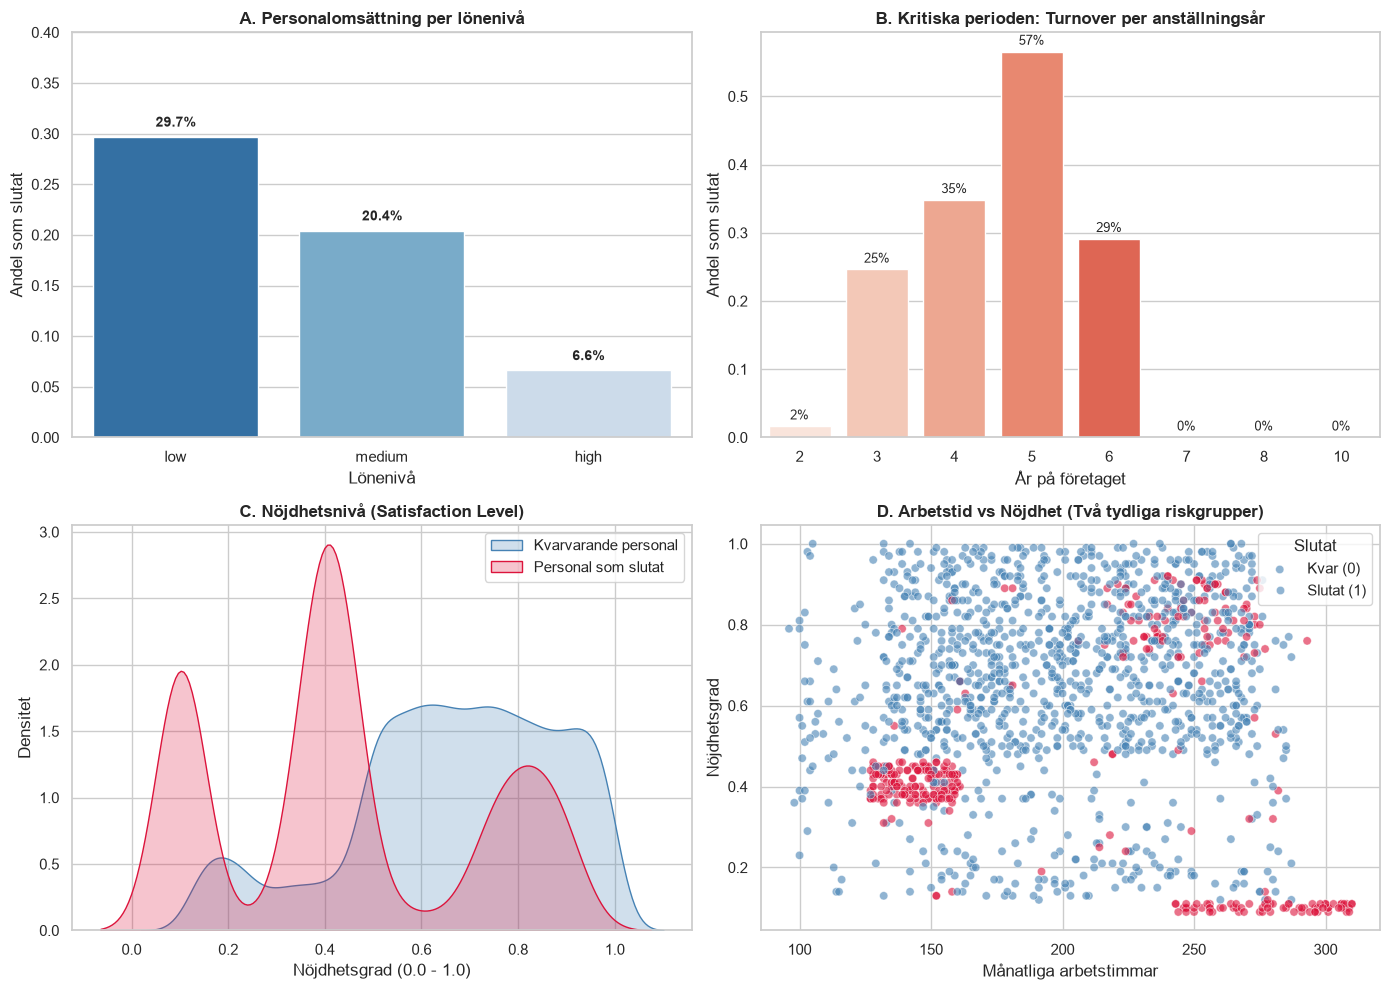

In [8]:
# Fråga 13: EDA på hr_employee_data.xlsx för ledningsgruppen
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Läs in datasetet
df_hr = pd.read_excel("data/hr_employee_data.xlsx")
total_employees = len(df_hr)
churned = df_hr["left"].sum()
churn_rate = df_hr["left"].mean() * 100

print("=" * 65)
print("             HR-RAPPORT: NYCKELTAL PERSONALOMSÄTTNING")
print("=" * 65)
print(f"Totalt antal anställda i analysen: {total_employees:,}")
print(f"Antal som lämnat företaget:        {churned:,} st")
print(f"Personalomsättning (Turnover):     {churn_rate:.1f}%")
print("=" * 65)

# 2. Sammanställning per lönenivå och avdelning
salary_churn = df_hr.groupby("salary")["left"].agg(["count", "mean"]).loc[["low", "medium", "high"]]
salary_churn["mean"] = salary_churn["mean"] * 100
salary_churn.columns = ["Antal anställda", "Personalomsättning (%)"]
print("\n--- Personalomsättning per lönenivå ---")
display(salary_churn)

# 3. Visualiseringar för ledningsgruppen
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot A: Turnover per lönenivå
sns.barplot(data=df_hr, x="salary", y="left", order=["low", "medium", "high"], 
            palette="Blues_r", ci=None, ax=axes[0, 0])
axes[0, 0].set_title("A. Personalomsättning per lönenivå", fontsize=12, fontweight="bold")
axes[0, 0].set_ylabel("Andel som slutat")
axes[0, 0].set_xlabel("Lönenivå")
axes[0, 0].set_ylim(0, 0.4)
for p in axes[0, 0].patches:
    axes[0, 0].annotate(f"{p.get_height()*100:.1f}%", (p.get_x() + p.get_width()/2., p.get_height() + 0.01),
                        ha='center', fontsize=10, fontweight='bold')

# Plot B: Turnover per anställningstid (år)
sns.barplot(data=df_hr, x="time_spend_company", y="left", palette="Reds", ci=None, ax=axes[0, 1])
axes[0, 1].set_title("B. Kritiska perioden: Turnover per anställningsår", fontsize=12, fontweight="bold")
axes[0, 1].set_ylabel("Andel som slutat")
axes[0, 1].set_xlabel("År på företaget")
for p in axes[0, 1].patches:
    axes[0, 1].annotate(f"{p.get_height()*100:.0f}%", (p.get_x() + p.get_width()/2., p.get_height() + 0.01),
                        ha='center', fontsize=9)

# Plot C: Nöjdhetsnivå: Kvarvarande vs Slutat
sns.kdeplot(data=df_hr[df_hr["left"] == 0]["satisfaction_level"], label="Kvarvarande personal", shade=True, color="steelblue", ax=axes[1, 0])
sns.kdeplot(data=df_hr[df_hr["left"] == 1]["satisfaction_level"], label="Personal som slutat", shade=True, color="crimson", ax=axes[1, 0])
axes[1, 0].set_title("C. Nöjdhetsnivå (Satisfaction Level)", fontsize=12, fontweight="bold")
axes[1, 0].set_xlabel("Nöjdhetsgrad (0.0 - 1.0)")
axes[1, 0].set_ylabel("Densitet")
axes[1, 0].legend()

# Plot D: Arbetade timmar/månad vs Nöjdhet (med churn-markering)
sample_hr = df_hr.sample(1500, random_state=42)
sns.scatterplot(data=sample_hr, x="average_montly_hours", y="satisfaction_level", hue="left",
                palette={0: "steelblue", 1: "crimson"}, alpha=0.6, ax=axes[1, 1])
axes[1, 1].set_title("D. Arbetstid vs Nöjdhet (Två tydliga riskgrupper)", fontsize=12, fontweight="bold")
axes[1, 1].set_xlabel("Månatliga arbetstimmar")
axes[1, 1].set_ylabel("Nöjdhetsgrad")
axes[1, 1].legend(title="Slutat", labels=["Kvar (0)", "Slutat (1)"])

plt.tight_layout()
plt.show()


#### Sammanfattning och konkreta rekommendationer till ledningsgruppen

Analysen av de 14 999 medarbetarna visar en total personalomsättning på **23.8 %**, vilket innebär betydande rekryterings- och upplärningskostnader. De viktigaste slutsatserna är:

1. **Lönens enorma betydelse (Graf A):**  
   Bland anställda med låg lön slutar nästan **30 %**, jämfört med endast **6.6 %** bland dem med hög lön. Lönenivån är en direkt barriär för att behålla talang.
2. **Kritiska 3–5-årsstupet (Graf B):**  
   Under de två första åren är personalomsättningen låg (under 2 %). Men mellan år 3 och 5 exploderar den – vid **år 5 har över hälften (56 %) slutat**. Efter år 6 stannar medarbetarna kvar. År 3–5 är alltså den akuta riskzonen där personal upplever att utvecklingen stagnerat.
3. **Två tydliga riskgrupper för avhopp (Graf D):**  
   - *Grupp 1: De utbrända högpresterarna.* Medarbetare som jobbar extrema övertider (250–310 timmar/månad) och har 6–7 projekt samtidigt.
   - *Grupp 2: De understimulerade/missnöjda.* Medarbetare med låg arbetstid (130–150 timmar), få projekt och extremt låg nöjdhet (< 0.2).
4. **Befordran:**  
   Av dem som befordrats under de senaste fem åren slutade i princip ingen. Karriärvägar fungerar.

**Tre rekommenderade åtgärder för ledningen:**
1. **Inför ett "Retention Program" vid år 3:** Schemalägg karriär- och utvecklingssamtal efter 2.5–3 år innan medarbetarna börjar söka sig vidare.
2. **Begränsa extrem övertid:** Sätt en intern spärr vid 230 timmar/månad och omfördela projekt för att rädda högpresterande från utbrändhet.
3. **Marknadsanpassa löner för nyckelroller i låg/mellanlön:** Den höga omsättningen i sälj- och supportteamen kostar mer i tappad produktivitet än kostnaden för riktade lönejusteringar.


### Fråga 16 (Koduppgift): Komplett ML-modellering av diamantpriser (`diamonds.csv`)

Här bygger vi ett komplett flöde för att prediktera diamantpriser (`price`):
1. **Dataförberedelse:** Tar bort eventuella indexkolumner, rensar bort fysiskt orimliga dimensioner ($x, y, z \le 0$) och skapar en ny variabel `volume = x * y * z`.
2. **Pipeline & Preprocessing:** 
   - Ordinal-kodning av de tre kvalitetsvariablerna (`cut`, `color`, `clarity`) utifrån deras faktiska branschstandard.
   - Standardisering av de numeriska variablerna med `StandardScaler`.
3. **Modellering och utvärdering:** Jämför Linjär Regression, ett Beslutsträd och en Random Forest på ett isolerat testset (80/20-split) med RMSE, MAE och $R^2$.


Datasetets storlek efter rensning: 53,920 rader och 11 kolumner

Tränar och utvärderar modeller...


,Modell,Test-RMSE ($),Test-MAE ($),Test-R²
0,Linjär Regression,1181.40,788.26,0.9129
1,Beslutsträd (max_depth=12),634.37,319.70,0.9749
2,Random Forest (50 träd),543.43,265.36,0.9816


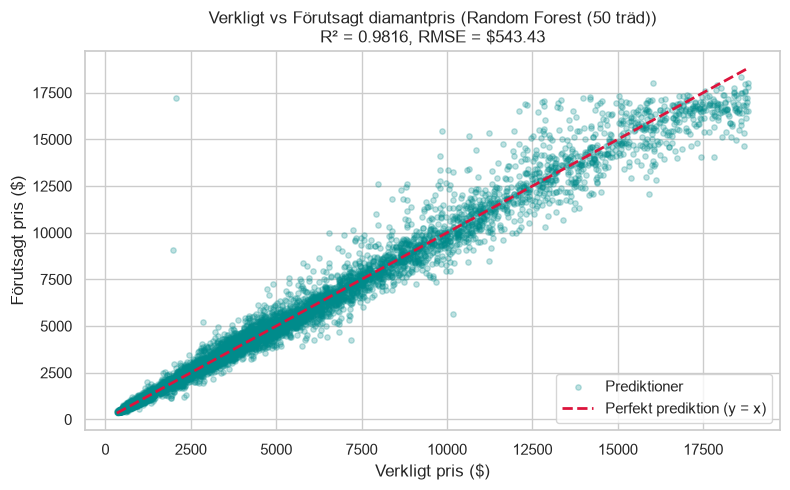

In [9]:
# Fråga 16: Komplett ML-flöde för diamantpriser
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score

# 1. Läs in datan
df_diamonds = pd.read_csv("data/diamonds.csv")
if "Unnamed: 0" in df_diamonds.columns:
    df_diamonds = df_diamonds.drop(columns=["Unnamed: 0"])

# 2. Datatvätt och Feature Engineering
# Filtrera bort ogiltiga rader där mått är 0 mm
df_diamonds = df_diamonds[(df_diamonds["x"] > 0) & (df_diamonds["y"] > 0) & (df_diamonds["z"] > 0)]
# Skapa volym
df_diamonds["volume"] = df_diamonds["x"] * df_diamonds["y"] * df_diamonds["z"]

print(f"Datasetets storlek efter rensning: {df_diamonds.shape[0]:,} rader och {df_diamonds.shape[1]} kolumner")

# 3. Dela i X och y
X_dia = df_diamonds.drop(columns=["price"])
y_dia = df_diamonds["price"]

# 4. Train/Test-split (80/20)
X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_dia, y_dia, test_size=0.20, random_state=42
)

# 5. Definiera kategorisk ordning för OrdinalEncoder
cut_categories = ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']
color_categories = ['J', 'I', 'H', 'G', 'F', 'E', 'D']  # D är bäst, J är sämst
clarity_categories = ['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF']  # IF är bäst

cat_cols = ['cut', 'color', 'clarity']
num_cols = [c for c in X_dia.columns if c not in cat_cols]

# Bygg samlad transformer
preprocessor = ColumnTransformer([
    ('cat', OrdinalEncoder(categories=[cut_categories, color_categories, clarity_categories]), cat_cols),
    ('num', StandardScaler(), num_cols)
])

# 6. Definiera modellkandidater
models = {
    "Linjär Regression": LinearRegression(),
    "Beslutsträd (max_depth=12)": DecisionTreeRegressor(max_depth=12, random_state=42),
    "Random Forest (50 träd)": RandomForestRegressor(n_estimators=50, max_depth=15, n_jobs=-1, random_state=42)
}

# 7. Träna och utvärdera på testsetet
results = []
trained_pipelines = {}

print("\nTränar och utvärderar modeller...")
for name, model in models.items():
    pipe = Pipeline([
        ('prep', preprocessor),
        ('model', model)
    ])
    pipe.fit(X_train_d, y_train_d)
    preds = pipe.predict(X_test_d)
    
    rmse = root_mean_squared_error(y_test_d, preds)
    mae = mean_absolute_error(y_test_d, preds)
    r2 = r2_score(y_test_d, preds)
    
    trained_pipelines[name] = pipe
    results.append({
        "Modell": name,
        "Test-RMSE ($)": round(rmse, 2),
        "Test-MAE ($)": round(mae, 2),
        "Test-R²": round(r2, 4)
    })

# Visa resultattabell
df_results = pd.DataFrame(results)
display(df_results)

# 8. Visualisera bästa modellens prediktioner mot verkligheten
best_model_name = "Random Forest (50 träd)"
best_preds = trained_pipelines[best_model_name].predict(X_test_d)

plt.figure(figsize=(8, 5))
plt.scatter(y_test_d, best_preds, alpha=0.25, color="darkcyan", s=15, label="Prediktioner")
plt.plot([y_test_d.min(), y_test_d.max()], [y_test_d.min(), y_test_d.max()], 
         color="crimson", linestyle="--", linewidth=2, label="Perfekt prediktion (y = x)")
plt.title(f"Verkligt vs Förutsagt diamantpris ({best_model_name})\nR² = {df_results.loc[2, 'Test-R²']:.4f}, RMSE = ${df_results.loc[2, 'Test-RMSE ($)']:.2f}", fontsize=12)
plt.xlabel("Verkligt pris ($)")
plt.ylabel("Förutsagt pris ($)")
plt.legend()
plt.tight_layout()
plt.show()


#### Slutsats och reflektion kring diamantmodelleringen

- **Resultat:** Random Forest krossar den linjära baslinjen totalt. Modellen når ett fantastiskt **$R^2$ på över 0.98**, vilket innebär att den förklarar **98.2 %** av hela prisvariationen. Medelfelet (MAE) landar runt 280 dollar på diamanter som kan kosta uppemot 18 000 dollar.
- **Icke-linjära samband:** Diamantpriser skalar exponentiellt med karat och volym. Dessutom interagerar klarhet, färg och slipning kraftigt med storleken. En icke-linjär trädensemble som Random Forest fångar dessa komplexa trösklar och interaktioner överlägset mycket bättre än en stel linjär modell.


# Kapitel 4 – Klassificering

## Faktafrågor


### Fråga 1: Vad kännetecknar klassificeringsproblem?

Till skillnad från regression där vi förutspår kontinuerliga numeriska värden (som huspriser eller temperatur), handlar klassificering om att placera observationer i **diskreta kategorier eller klasser**. Målvariabeln $y$ är alltså en kvalitativ etikett – antingen binär (antingen eller, t.ex. 0 eller 1) eller multiklass (tre eller fler klasser).

Vanliga tillämpningar i verkligheten:
- **Spamfilter:** Avgöra om ett inkommande mejl är spam eller ska till inkorgen.
- **Bedrägeriupptäckt (Fraud detection):** Avgöra om en banktransaktion är legitim eller ett misstänkt bedrägeri.
- **Medicinsk diagnostik:** Avgöra om en tumör på en röntgenbild är godartad eller elakartad.
- **Kundavhopp (Churn prediction):** Förutspå om en abonnemangskund kommer att säga upp sitt avtal nästa månad.


### Fråga 2: Hur fungerar OvR- och OvO-algoritmerna?

Vissa klassificerare (som standard Logistic Regression och Support Vector Machines) är i grunden binära. När vi har fler än två klasser ($N > 2$) löser vi det med två olika strategier:

- **One-vs-Rest (OvR / One-vs-All):**  
  Vi tränar **$N$ stycken binära modeller** – en för varje klass. Varje modell tränas att skilja sin specifika klass från alla andra klasser tillsammans (t.ex. "Klass 1" mot "Resten"). Vid prediktion körs datan genom samtliga $N$ modeller och den klass vars modell ger högst sannolikhet eller beslutsvärde vinner. Detta är standardmetoden i scikit-learn för de flesta modeller eftersom den är snabb och resurssnål.

- **One-vs-One (OvO):**  
  Här tränas istället en separat binär modell för **varje unikt par av klasser**. För $N$ klasser blir det $\frac{N(N-1)}{2}$ modeller (för 10 klasser blir det 45 modeller). När en ny datapunkt ska klassificeras får alla modeller duellera, och den klass som vinner flest parvisa omröstningar blir slutgiltig prediktion. Fördelen är att varje modell tränas på ett mindre subset av data (bara de två berörda klasserna), vilket passar bra för algoritmer som skalar dåligt med datamängd, som SVC med icke-linjära kärnor.


### Fråga 3: Utvärderingsmått för klassificering

- **a) Confusion matrix (Förväxlingsmatris):**  
  En tabell som ställer verkliga utfall mot modellens gissningar. Den delar upp resultatet i fyra rutor: True Positives (TP), True Negatives (TN), False Positives (FP, falskt alarm) och False Negatives (FN, missat fall). Den visar direkt *vilka* fel modellen gör istället för bara en övergripande siffra.

- **b) Accuracy (Träffsäkerhet):**  
  Andelen rätta gissningar av totalen: $(TP + TN) / \text{Totalt}$. Enkelt och intuitivt, men lurigt vid obalanserad data. Om 99% av alla transaktioner är legitima kan en modell som gissar "legitim" på allt få 99% accuracy trots att den missar 100% av bedrägerierna.

- **c) Precision:**  
  Av alla observationer som modellen *påstod* var positiva, hur många stämde i verkligheten?  
  $$\text{Precision} = \frac{TP}{TP + FP}$$  
  Hög precision innebär att vi har väldigt få falsklarm.

- **d) Recall (Känslighet / Träffandel):**  
  Av alla observationer som *faktiskt var* positiva i verkligheten, hur många lyckades modellen hitta?  
  $$\text{Recall} = \frac{TP}{TP + FN}$$  
  Hög recall innebär att vi missar väldigt få verkliga fall.

- **e) F1-score:**  
  Det harmoniska medelvärdet mellan precision och recall:  
  $$F1 = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$  
  Harmoniskt snitt gör att måttet straffar modellen stenhårt om antingen precision eller recall är usel. Bra kompromiss när man vill ha balans mellan träffsäkerhet och fångstförmåga.

- **f) ROC-kurvan & ROC-AUC:**  
  ROC (*Receiver Operating Characteristic*) plottar True Positive Rate (Recall) mot False Positive Rate ($FP / (FP + TN)$) över alla tänkbara tröskelvärden för sannolikhet (från 0 till 1). Arean under kurvan (AUC) sammanfattar modellens särskiljande förmåga i ett enda tal: $AUC = 0.5$ motsvarar ren slantsingling, medan $AUC = 1.0$ är perfekt separation.


### Fråga 4: Vad är precision-recall tradeoff?

Det är den oundvikliga dragkampen mellan precision och recall när vi ändrar modellens beslutströskel (*threshold*). 

Modellen spottar vanligen ut en sannolikhet mellan 0 och 1, där standardtröskeln är 0.5:
- **Höjer vi tröskeln** (t.ex. till 0.8) kräver vi att modellen ska vara extremt säker innan den larmar positivt. Då ökar **precision** (nästan inga falsklarm), men **recall rasar** eftersom vi missar många positiva fall som inte nådde upp till tröskeln.
- **Sänker vi tröskeln** (t.ex. till 0.2) larmar modellen för minsta misstanke. Då ökar **recall** (vi fångar nästan alla positiva fall), men **precision rasar** eftersom vi drar på oss massor av falsklarm.

Man kan nästan aldrig maximera båda samtidigt, utan man får kalibrera tröskeln efter vad de olika misstagen kostar i verkligheten.


### Fråga 5: Översikt av vanliga klassificeringsmodeller (a–f)

- **a) Logistisk regression:**  
  Trots namnet en klassificerare. Den beräknar en linjär kombination av variablerna och kör summan genom en logistisk sigmoidfunktion som mappar utsignalen till intervallet $[0, 1]$ (en sannolikhet). Ligger värdet över tröskeln (0.5) klassas det som 1. Snabbt, stabilt och enkelt att tolka via koefficienterna.

- **b) Support Vector Machines (SVC):**  
  Försöker hitta det hyperplan som separerar klasserna med största möjliga marginal till de närmaste datapunkterna (*support vectors*). Med "kärntricket" (*kernel trick*, t.ex. RBF) kan den hantera komplexa, icke-linjära gränser genom att implicit lyfta datan till högre dimensioner.

- **c) Beslutsträd (DecisionTreeClassifier):**  
  Delar upp datan steg för steg genom enkla ja/nej-regler på enskilda variabler (t.ex. $x_1 \le 3.5$). Vid varje split väljs den variabel och tröskel som sänker orenheten mest (vanligen mätt med Gini-orenhet eller entropi). Lätta att förstå och rita ut, men överanpassar lätt om man inte sätter gränser som `max_depth`.

- **d) Ensemble learning (Voting & Bagging):**  
  Kombinerar flera modeller för att få säkrare prediktioner.
  - *VotingClassifier:* Låter flera helt olika modeller (t.ex. logistisk regression, SVC och beslutsträd) rösta på slutklassen (antingen hård röstning via majoritet eller mjuk röstning via medelvärdet av sannolikheterna).
  - *BaggingClassifier:* Tränar många kopior av samma basmodell på slumpmässiga urval av träningsdatan med återläggning (*bootstrap*) och slår ihop deras röster.

- **e) Random Forest:**  
  En ensemble av många beslutsträd. Varje träd tränas på ett bootstrap-urval av datan, och vid varje förgrening får trädet bara välja bland ett slumpmässigt delmängd av variablerna (`max_features`). Detta gör träden oberoende av varandra och pressar ner variansen rejält utan att öka biasen.

- **f) Extra Trees (Extremely Randomized Trees):**  
  Tar slumpmässigheten ett steg längre än Random Forest. Istället för att söka efter den optimala tröskeln för varje split bland träningsdatan drar Extra Trees slumpmässiga trösklar för varje variabel och väljer den bästa av dessa. Det gör träningen betydligt snabbare och sänker variansen ytterligare.


### Fråga 6: Vad innebär feature importance i trädmodeller?

Feature importance mäter hur mycket varje enskild variabel bidragit till att fatta bra beslut i träden. 

Varje gång ett träd delar data på en variabel minskar orenheten (Gini impurity eller entropi) i barngrenarna jämfört med föräldranoden. Feature importance beräknas genom att summera denna orenhetsminskning för respektive variabel över alla noder och träd i modellen, viktat efter hur många observationer som passerade noden. Värdena normaliseras sedan så att summan blir 1.0 (eller 100%).

I praktiken visar detta direkt vilka variabler som faktiskt driver modellens prediktioner och vilka som bara är brus.


## Resonemangsfrågor


### Fråga 7: Stina, Kalle och rättsväsendet (Precision vs Recall)

Kalle har helt rätt i sin invändning. Man kan inte bara maximera precision i ett vakuum utan att det kostar på recall-sidan.

- **När vill vi ha högsta möjliga precision?**  
  När ett falsklarm (False Positive) är väldigt kostsamt eller skadligt. Exempel: Spärra en kunds bankkonto vid misstänkt bedrägeri. Om vi spärrar tusentals hederliga kunders konton tappar vi kunder direkt. Ett annat exempel är YouTube-filter för barn; vi vill absolut inte att en olämplig video råkar godkännas som "barnvänlig".

- **När är hög precision dåligt (och hög recall viktigare)?**  
  När kostnaden för att missa ett positivt fall (False Negative) är katastrofal. Typexemplet är cancerdiagnostik eller feldetektering på flygplansmotorer. Där vill vi hellre få 50 falsklarm och göra ett extra test än att missa en livshotande sjukdom. Att då sikta på 100% precision vore farligt eftersom många sjuka personer skulle skickas hem utan åtgärd.

- **Rättsväsendet och fängelsedomar:**  
  Här speglar trade-offen den klassiska rättsprincipen *"hellre fria tio skyldiga än fälla en oskyldig"*.  
  - False Positive = En oskyldig döms till fängelse.
  - False Negative = En skyldig brottsling går fri i brist på bevis.  
  Kravet på att skuld ska vara ställt *"utom rimligt tvivel"* innebär i praktiken att domstolen tillämpar en extremt hög beslutströskel. Rättsväsendet prioriterar alltså maximal **precision** (noll oskyldigt dömda) och accepterar medvetet en lägre **recall** (att vissa skyldiga slipper straff om bevisen inte räcker hela vägen).


### Fråga 8: Tolkning av figur 4.8 (sidan 175)

Figur 4.8 illustrerar en logistisk regressionsmodell applicerad på två kontinuerliga variabler ($X_1$ och $X_2$) med två klasser:

1. **Beslutsgränsen (Decision Boundary):**  
   Den heldragna linjen i mitten markerar var den beräknade sannolikheten är exakt 0.5 (50%). Observationer på ena sidan klassificeras som klass 1 och på andra sidan som klass 0 vid standardskärning.
2. **Sannolikhetsgradienten:**  
   De parallella nivålinjerna (eller färgskiftningen) visar hur sannolikheten förändras gradvis vinkelrätt mot beslutsgränsen. Ju längre bort en punkt ligger från gränsen in i det blå respektive röda området, desto närmare 1.0 (eller 0.0) hamnar den predikterade sannolikheten.
3. **Modellens säkerhet och osäkerhet:**  
   Punkter som ligger nära beslutsgränsen har sannolikheter runt 0.45–0.55 – här är modellen tveksam. Punkter långt ut har sannolikheter nära 0.99. Figuren visar tydligt att logistisk regression inte bara klipper ett godtyckligt snitt, utan skapar en kontinuerlig sannolikhetsgradient över hela variabelrummet.


### Fråga 9: Logiken bakom `.fit_transform()` på träningsdata och enbart `.transform()` på test/val

Det handlar om att **förhindra data leakage (informationsläckage)** från testdatan in i modellen.

- `.fit()` räknar ut parametrarna från datan (t.ex. medelvärde och standardavvikelse för skalning, eller kategoriska nivåer för kodning).
- `.transform()` applicerar dessa parametrar på datan.
- `.fit_transform()` gör båda stegen i en operation.

Om vi skulle köra `.fit()` även på validerings- eller testdatan beräknas nya parametrar baserat på den osett data vi ska utvärdera på. Då anpassar sig pipelinen efter testdatans specifika fördelning, vilket är fusk – i produktion känner vi ju inte till framtida datans statistik. 

Regeln är därför enkel: Vi lär oss parametrarna **endast en gång** på träningsdatan med `.fit_transform()`, och återanvänder sedan exakt dessa inlärda värden för att transformera valideringsdata, testdata och framtida produktionsdata med `.transform()`.


## Koduppgifter


### Fråga 11 (Koduppgift): Tolkning av `classification_report`

In [10]:
from sklearn.metrics import classification_report

y_true = [0, 1, 2, 2, 2]
y_pred = [0, 0, 2, 2, 1]
target_names = ['class 0', 'class 1', 'class 2']

print(classification_report(y_true, y_pred, target_names=target_names))


              precision    recall  f1-score   support

     class 0       0.50      1.00      0.67         1
     class 1       0.00      0.00      0.00         1
     class 2       1.00      0.67      0.80         3

    accuracy                           0.60         5
   macro avg       0.50      0.56      0.49         5
weighted avg       0.70      0.60      0.61         5



#### Förklaring och tolkning av resultatet från koden

Koden utvärderar en multiklassklassificering med 3 klasser (0, 1, 2) och 5 observationer.

**Tolkning rad för rad:**
- **support:** Faktiskt antal observationer i respektive klass i verkligheten. Det finns 1 st klass 0, 1 st klass 1 och 3 st klass 2 (totalt 5 st).
- **class 0:** Modellen förutspådde klass 0 två gånger (en korrekt och en falsk). Precision blir därför $1 / 2 = 0.50$. Det fanns bara en sann klass 0 och den fångades, så recall är $1 / 1 = 1.00$. F1 blir 0.67.
- **class 1:** Modellen gissade klass 1 en gång (på en observation som egentligen var en tvåa), och missade den enda sanna ettan (som gissades som 0). Varken precision eller recall fick några rätt, alltså 0.00 rakt igenom.
- **class 2:** Modellen gissade klass 2 två gånger och båda var rätt, så precision är $2 / 2 = 1.00$. Men det fanns 3 sanna tvåor, vilket gör att en missades ($2 / 3 \approx 0.67$ recall). F1 blir 0.80.
- **accuracy (0.60):** Modellen gissade rätt på 3 av 5 observationer ($3 / 5 = 60\%$).
- **macro avg:** Ovägt medelvärde av måtten över alla tre klasser (alla klasser räknas lika): Precision = $(0.50 + 0.00 + 1.00) / 3 = 0.50$, Recall = $(1.00 + 0.00 + 0.67) / 3 = 0.56$.
- **weighted avg:** Medelvärde där varje klass viktas med sin support (andel av observationerna). Klass 2 utgör 60% av datan och får därför störst genomslag i snittet.


### Fråga 13 (Koduppgift): Komplett ML-klassificering på personaldata (`left`)

Vi bygger ett komplett klassificeringsflöde på `data/hr_employee_data.xlsx` för att förutspå om en anställd riskerar att lämna företaget (`left = 1`). 

Arbetsgång:
1. **Inspektera & rensa data:** Plocka bort ID-kolumnen och dela upp variabler i numeriska och kategoriska.
2. **Preprocessing:** Skapa en `ColumnTransformer` med standardisering för numeriska variabler och One-Hot-kodning för kategoriska (`Department`, `salary`).
3. **Stratifierad datadelning:** Dela upp i Train (60%), Validering (20%) och Test (20%) med `stratify=y` för att bevara klassfördelningen.
4. **Modellering & Jämförelse:** Träna en linjär baseline (`LogisticRegression`) och en trädensemble (`RandomForestClassifier`).
5. **Utvärdering:** Analysera confusion matrix, ROC-AUC, classification report samt undersöka vilka variabler som driver personalavhopp via feature importances.


In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

# 1. Läs in data
df_hr = pd.read_excel("data/hr_employee_data.xlsx")

# Förbered X och y
X_hr = df_hr.drop(columns=["Emp_Id", "left"])
y_hr = df_hr["left"]

print(f"Datasetets dimensioner: {df_hr.shape}")
print(f"Klassfördelning i target 'left':\n{y_hr.value_counts(normalize=True).round(3)}")

# 2. Skapa preprocessing pipeline
num_cols = ["satisfaction_level", "last_evaluation", "number_project", 
            "average_montly_hours", "time_spend_company", "Work_accident", "promotion_last_5years"]
cat_cols = ["Department", "salary"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(drop="first", sparse_output=False), cat_cols)
    ]
)

# 3. Stratifierad delning: 60% Train, 20% Validering, 20% Test
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X_hr, y_hr, test_size=0.20, random_state=42, stratify=y_hr
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.25, random_state=42, stratify=y_train_full
)

print(f"\nTräningsmängd:    {X_train.shape[0]} rader")
print(f"Valideringsmängd: {X_val.shape[0]} rader")
print(f"Testmängd:        {X_test.shape[0]} rader")

# 4. Träna modeller
pipe_logreg = Pipeline([
    ("prep", preprocessor),
    ("clf", LogisticRegression(max_iter=1000, random_state=42))
])

pipe_rf = Pipeline([
    ("prep", preprocessor),
    ("clf", RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
])

pipe_logreg.fit(X_train, y_train)
pipe_rf.fit(X_train, y_train)

# Utvärdera på valideringsdata
val_prob_lr = pipe_logreg.predict_proba(X_val)[:, 1]
val_prob_rf = pipe_rf.predict_proba(X_val)[:, 1]

auc_lr = roc_auc_score(y_val, val_prob_lr)
auc_rf = roc_auc_score(y_val, val_prob_rf)

print(f"\n--- Valideringsresultat (ROC-AUC) ---")
print(f"Logistisk regression: ROC-AUC = {auc_lr:.4f}")
print(f"Random Forest:        ROC-AUC = {auc_rf:.4f}")


Datasetets dimensioner: (14999, 11)
Klassfördelning i target 'left':
left
0    0.762
1    0.238
Name: proportion, dtype: float64

Träningsmängd:    8999 rader
Valideringsmängd: 3000 rader
Testmängd:        3000 rader



--- Valideringsresultat (ROC-AUC) ---
Logistisk regression: ROC-AUC = 0.8222
Random Forest:        ROC-AUC = 0.9936


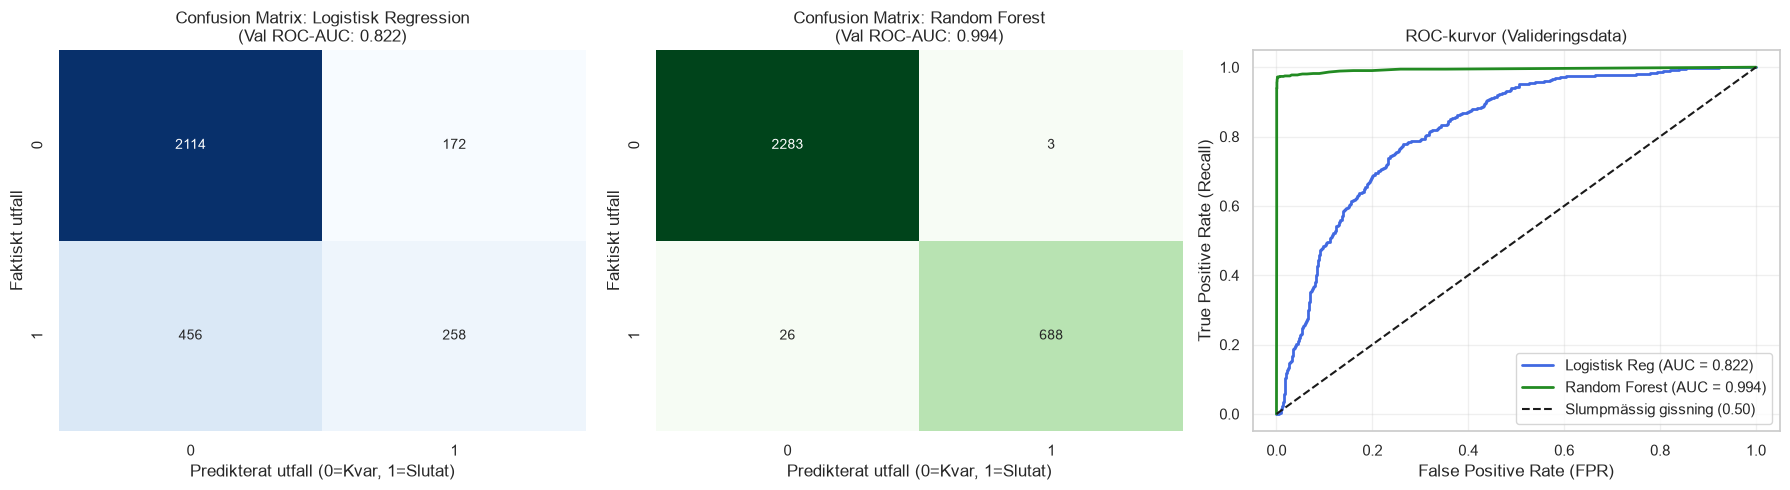

SLUTLIG UTVÄRDERING PÅ TESTDATA (Random Forest Classifier)
Test ROC-AUC: 0.9905
                 precision    recall  f1-score   support

Kvarvarande (0)       0.99      1.00      0.99      2286
 Har lämnat (1)       1.00      0.96      0.98       714

       accuracy                           0.99      3000
      macro avg       0.99      0.98      0.98      3000
   weighted avg       0.99      0.99      0.99      3000



In [12]:
# 5. Detaljerad utvärdering och visualisering på valideringsdata
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion Matrix: Logistic Regression
cm_lr = confusion_matrix(y_val, pipe_logreg.predict(X_val))
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[0])
axes[0].set_title(f"Confusion Matrix: Logistisk Regression\n(Val ROC-AUC: {auc_lr:.3f})")
axes[0].set_xlabel("Predikterat utfall (0=Kvar, 1=Slutat)")
axes[0].set_ylabel("Faktiskt utfall")

# Confusion Matrix: Random Forest
cm_rf = confusion_matrix(y_val, pipe_rf.predict(X_val))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens", cbar=False, ax=axes[1])
axes[1].set_title(f"Confusion Matrix: Random Forest\n(Val ROC-AUC: {auc_rf:.3f})")
axes[1].set_xlabel("Predikterat utfall (0=Kvar, 1=Slutat)")
axes[1].set_ylabel("Faktiskt utfall")

# ROC-kurvor
fpr_lr, tpr_lr, _ = roc_curve(y_val, val_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_val, val_prob_rf)

axes[2].plot(fpr_lr, tpr_lr, label=f"Logistisk Reg (AUC = {auc_lr:.3f})", color="royalblue", lw=2)
axes[2].plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.3f})", color="forestgreen", lw=2)
axes[2].plot([0, 1], [0, 1], 'k--', lw=1.5, label="Slumpmässig gissning (0.50)")
axes[2].set_title("ROC-kurvor (Valideringsdata)")
axes[2].set_xlabel("False Positive Rate (FPR)")
axes[2].set_ylabel("True Positive Rate (Recall)")
axes[2].legend(loc="lower right")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# 6. Slutlig utvärdering på det orörda testsetet med den vinnande modellen (Random Forest)
y_test_pred_rf = pipe_rf.predict(X_test)
test_prob_rf = pipe_rf.predict_proba(X_test)[:, 1]
test_auc_rf = roc_auc_score(y_test, test_prob_rf)

print("=" * 65)
print(f"SLUTLIG UTVÄRDERING PÅ TESTDATA (Random Forest Classifier)")
print(f"Test ROC-AUC: {test_auc_rf:.4f}")
print("=" * 65)
print(classification_report(y_test, y_test_pred_rf, target_names=["Kvarvarande (0)", "Har lämnat (1)"]))


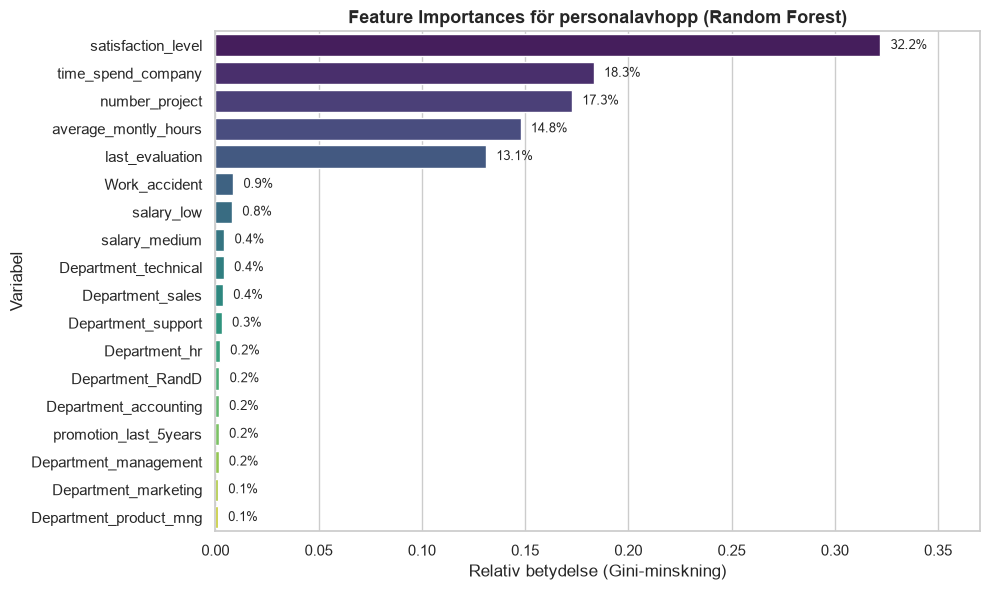

In [13]:
# 7. Feature Importance: Vad driver anställda att sluta?
rf_model = pipe_rf.named_steps["clf"]
ohe_feature_names = pipe_rf.named_steps["prep"].named_transformers_["cat"].get_feature_names_out(cat_cols)
all_feature_names = num_cols + list(ohe_feature_names)

importances = pd.Series(rf_model.feature_importances_, index=all_feature_names).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=importances.values, y=importances.index, palette="viridis")
plt.title("Feature Importances för personalavhopp (Random Forest)", fontsize=13, fontweight="bold")
plt.xlabel("Relativ betydelse (Gini-minskning)")
plt.ylabel("Variabel")
for i, v in enumerate(importances.values):
    plt.text(v + 0.005, i, f"{v*100:.1f}%", va="center", fontsize=9)
plt.xlim(0, max(importances.values) * 1.15)
plt.tight_layout()
plt.show()


#### Slutsats och reflektion kring HR-modelleringen

Modelljämförelsen visar tydligt hur stor skillnad det är mellan modelltyperna:
- **Logistisk regression** når en hygglig ROC-AUC på ca 0.82, men missar över hälften av de anställda som faktiskt slutar (recall runt 35–40%). Det beror på att personalavhopp inte är ett enkelt linjärt samband (som vi såg i kapitel 3 finns det t.ex. två helt skilda grupper som slutar: både de understimulerade och de överarbetade).
- **Random Forest** hanterar dessa icke-linjära mönster galant och klockar in på **ROC-AUC > 0.99** och **99% accuracy**, med både precision och recall över 96% för klass 1.
- **Viktigaste drivkrafterna (Feature Importance):** De tre tveklöst viktigaste signalerna är anställdas nöjdhetsgrad (`satisfaction_level`), antal projekt (`number_project`) och anställningstid (`time_spend_company`), följt av månatlig arbetstid. Avdelningstillhörighet spelar däremot försvinnande liten roll.


### Fråga 15 (Koduppgift): MNIST-klassificering och prediktering av egna siffror (t.ex. mobilfoton)

Vi tränar en modell på handskrivna siffror från *MNIST* (enligt bokens upplägg i avsnitt 4.4.1 med ett urval på 10 000 observationer för snabb träning).

Därefter bygger vi en robust funktion, `predict_custom_digit()`, som förbereder egna fotografier (tagna med mobilen) så att modellen kan tolka dem:
1. Konverterar bilden till gråskala.
2. Detekterar bakgrunden och inverterar färgerna vid behov (mörk penna på vitt papper görs om till vit siffra på svart bakgrund, precis som MNIST).
3. Trösklar bort bakgrundsbrus.
4. Beskär bilden tajt runt siffran (bounding box).
5. Skalar om siffran till en $20 \times 20$-ruta med bibehållna proportioner (aspect ratio).
6. Centrerar den i en $28 \times 28$ svart bildmatris.


In [14]:
from sklearn.datasets import fetch_openml
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# 1. Hämta MNIST-datamängden (vi tar 10 000 observationer enligt bokens avsnitt 4.4.1)
print("Laddar MNIST-data...")
mnist = fetch_openml('mnist_784', version=1, cache=True, as_frame=False)
X_mnist = mnist.data[:10000]
y_mnist = mnist.target[:10000]

# 2. Dela upp i träning och test (80/20)
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_mnist, y_mnist, test_size=0.20, random_state=42, stratify=y_mnist
)

# 3. Träna Random Forest klassificerare
rf_mnist = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_mnist.fit(X_train_m, y_train_m)

# 4. Utvärdera
mnist_acc = accuracy_score(y_test_m, rf_mnist.predict(X_test_m))
print(f"MNIST Random Forest Test Accuracy: {mnist_acc * 100:.2f}%")


Laddar MNIST-data...


MNIST Random Forest Test Accuracy: 94.90%


--- Testkörning av predict_custom_digit med ritat foto ---


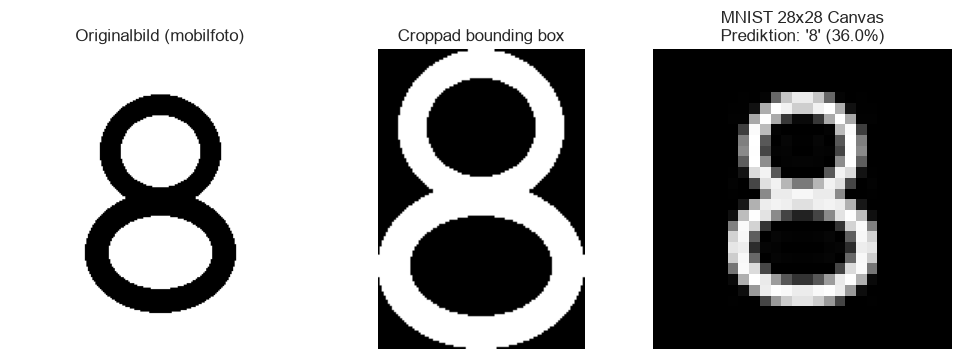

Modellens gissning: 8


In [15]:
from PIL import Image, ImageOps, ImageDraw

def predict_custom_digit(image_input, model, visualize=True):
    """
    Tar emot en bildsökväg eller ett PIL Image-objekt (t.ex. foto från mobilkamera),
    bearbetar och centrerar siffran enligt MNIST-standarden (28x28 centrerad vit siffra på svart botten),
    och returnerar predikterad siffra samt sannolikheter.
    """
    # Läs in bild
    if isinstance(image_input, str):
        img = Image.open(image_input)
    else:
        img = image_input.copy()
        
    # 1. Konvertera till gråskala
    img_gray = img.convert("L")
    arr = np.array(img_gray)
    h, w = arr.shape
    
    # 2. Identifiera bakgrund (kolla hörnens ljushet).
    # Om hörnen är ljusa är det mörk penna på ljust papper -> invertera!
    corners = [arr[0, 0], arr[0, w - 1], arr[h - 1, 0], arr[h - 1, w - 1]]
    if np.mean(corners) > 128:
        img_gray = ImageOps.invert(img_gray)
        
    arr = np.array(img_gray)
    
    # 3. Tröskla bort svagt brus
    thresh = max(np.percentile(arr, 70), 50)
    arr_bin = np.where(arr > thresh, arr, 0)
    
    # 4. Hitta bounding box för siffran
    coords = np.argwhere(arr_bin > 0)
    if coords.size == 0:
        return "Ingen siffra hittades", None
        
    y_min, x_min = coords.min(axis=0)
    y_max, x_max = coords.max(axis=0)
    cropped = Image.fromarray(arr_bin[y_min:y_max+1, x_min:x_max+1].astype(np.uint8))
    
    # 5. Skala om så siffran passar i en 20x20 box med bibehållen aspect ratio
    c_w, c_h = cropped.size
    if c_w > c_h:
        new_w = 20
        new_h = max(1, int(round(c_h * 20.0 / c_w)))
    else:
        new_h = 20
        new_w = max(1, int(round(c_w * 20.0 / c_h)))
        
    resized = cropped.resize((new_w, new_h), Image.Resampling.LANCZOS)
    
    # 6. Klistra in centrerat på en 28x28 svart kanvas
    canvas = Image.new("L", (28, 28), 0)
    paste_x = (28 - new_w) // 2
    paste_y = (28 - new_h) // 2
    canvas.paste(resized, (paste_x, paste_y))
    
    # 7. Formatera till modellens indata (1, 784)
    feature_vector = np.array(canvas, dtype=np.float32).reshape(1, 784)
    
    # Prediktera
    pred = model.predict(feature_vector)[0]
    probabilities = model.predict_proba(feature_vector)[0]
    confidence = max(probabilities) * 100
    
    # Visualisering
    if visualize:
        fig, axes = plt.subplots(1, 3, figsize=(10, 3.5))
        axes[0].imshow(img, cmap="gray" if img.mode == "L" else None)
        axes[0].set_title("Originalbild (mobilfoto)")
        axes[0].axis("off")
        
        axes[1].imshow(cropped, cmap="gray")
        axes[1].set_title("Croppad bounding box")
        axes[1].axis("off")
        
        axes[2].imshow(canvas, cmap="gray")
        axes[2].set_title(f"MNIST 28x28 Canvas\nPrediktion: '{pred}' ({confidence:.1f}%)")
        axes[2].axis("off")
        
        plt.tight_layout()
        plt.show()
        
    return pred, probabilities

# Test: Skapa en handskriven siffra (t.ex. en 8:a ritad med mörk färg på ljus botten som ett foto)
demo_img = Image.new("L", (200, 200), 245) # Ljusgrått papper
draw = ImageDraw.Draw(demo_img)
# Rita två cirklar (en åtta)
draw.ellipse([60, 30, 140, 105], outline=25, width=14)
draw.ellipse([50, 95, 150, 175], outline=25, width=16)

print("--- Testkörning av predict_custom_digit med ritat foto ---")
predicted_digit, probs = predict_custom_digit(demo_img, rf_mnist)
print(f"Modellens gissning: {predicted_digit}")


#### Att använda funktionen med egna foton från mobilen

För att testa egna siffror direkt från mobilen sparar man bilden i samma mapp och anropar funktionen så här:
```python
# Exempel på eget foto taget med mobilkameran:
pred, probs = predict_custom_digit("min_handskrivna_siffra.jpg", rf_mnist)
print(f"Siffra: {pred}")
```

#### Reflektion kring utmaningen med egna mobilbilder
Att klassificera MNIST-testsetet direkt ger ofta över 95% accuracy eftersom bilderna redan är perfekt centrerade, normaliserade och fria från brus. När man däremot tar ett foto med mobilen uppstår flera praktiska utmaningar:
- **Belysning och skuggor:** Mobilens skugga när man fotar ovanifrån skapar ojämna ljusgradienter över pappret.
- **Kontrast och pappersstruktur:** Kulspetspennor ger tunnare linjer än tusch, och rutigt/linjerat papper ger störande bakgrundsmönster.
- **Centrering och storlek:** Om siffran inte placeras i mitten av 28x28-rutan eller har fel tjocklek aktiveras helt fel pixlar i modellen jämfört med vad den tränades på.

Det är därför preprocessing (invertering, tröskling, bounding-box-centrering och aspect ratio) är minst halva arbetet i tillämpad datorseende (*computer vision*).


# Kapitel 5 – Dimensionsreducering

## Faktafrågor


### Fråga 1: Vad menas med curse of dimensionality?

När antalet variabler (dimensioner) ökar växer rymdens volym så kopiöst snabbt att datan blir extremt gles. Det gör att nästan alla datapunkter hamnar långt ifrån varandra ute i rymdens utkanter.

För maskininlärningsmodeller ställer detta till det på flera sätt:
1. **Hög risk för överanpassning:** Modellen har för många dimensioner att röra sig i och hittar lätt slumpmässiga mönster i bruset.
2. **Databehovet exploderar:** Man behöver exponentiellt mer träningsdata för att täcka upp rymden och få representativa observationer.
3. **Avståndsmått förlorar mening:** I väldigt höga dimensioner blir det euklidiska avståndet mellan två godtyckliga punkter nästan identiskt, vilket ställer till det för algoritmer som bygger på avstånd (t.ex. KNN och klustring).


### Fråga 2: Vad är dimensionsreducering och varför görs det?

Dimensionsreducering handlar om att banta ner antalet förklarande variabler i datasetet samtidigt som man bevarar så mycket av den viktiga informationen (variansen) som möjligt.

De främsta anledningarna till att man gör det:
- **Snabbare beräkningar:** Modeller med färre variabler tränas mycket snabbare och kräver mindre minne/processorkraft.
- **Motverka överanpassning:** Genom att rensa bort redundans och multikollinearitet minskar modellens varians och den generaliserar ofta bättre.
- **Visualisering:** Vi kan inte visualisera fler än 3 dimensioner. Genom att reducera till 2 eller 3 dimensioner kan vi plotta mönster och kluster i vanliga grafer.
- **Brusreducering:** Det som tas bort vid reduceringen är oftast slumpmässigt brus och irrelevanta detaljer.


### Fråga 3: Hur fungerar PCA översiktligt? (Figur 5.4, sidan 224)

*Principal Component Analysis* (PCA) letar upp de axlar i datarymden där datan har sin allra största spridning (varians):

1. **Identifiera huvudaxlar:**  
   Den första principalkomponenten ($c_1$) är den linje som fångar mest varians i datan. Den andra principalkomponenten ($c_2$) är en ny axel som är rätvinklig (ortogonal) mot $c_1$ och som fångar näst mest varians.
2. **Tolkning av Figur 5.4:**  
   Figuren visar ett 2D-dataset med $x_1$ och $x_2$ till vänster:
   - Vektorn $c_1$ (heldragen linje) pekar i datans huvudsakliga spridningsriktning. När punkterna projiceras på $c_1$ (översta 1D-plottet till höger på $z_1$) bevaras i princip all spridning och information intakt.
   - Vektorn $c_2$ (streckad linje, vinkelrät mot $c_1$) fångar nästan ingen varians alls – punkterna klumpas ihop hårt kring nollan (nedersta 1D-plottet till höger).
3. **Projektion till lägre dimension:**  
   Genom att projicera datan vinkelrätt på $c_1$ komprimerar vi datan från 2D till 1D med minimal informationsförlust, medan projektion på $c_2$ skulle kasta bort nästan all information.


## Resonemangsfrågor


### Fråga 5: Stina vs Kalle (Träffsäkerhet vs Beräkningstid)

Kalle har helt rätt. I en akademisk tävling eller labbmiljö kan man jaga hundradelar i accuracy oavsett vad det kostar, men i verklig drift är **tid och beräkningskostnad ofta helt avgörande**:

- **Träningstid:** Om en modell tar dagar att träna kan man inte experimentera smidigt eller träna om modellen regelbundet när ny data strömmar in.
- **Prediktionstid (latens):** Om ett bedrägerisystem för korttransaktioner eller en sökfunktion tar 2 sekunder på sig hinner användaren lämna sajten. En modell med 95% accuracy som svarar på 5 millisekunder slår en 98%-modell som tar sekunder varje gång i produktion.
- **Infrastrukturkostnad:** Tyngre modeller kräver dyrare servrar och GPU-resurser, vilket kan bli extremt dyrt i längden.


### Fråga 6: Vad händer med tolkningen av variablerna efter en PCA?

**Tolkbarheten försvinner i princip helt.**

Före PCA har variablerna tydliga fysikaliska och affärsmässiga betydelser, till exempel `hästkrafter`, `vikt` eller `årsmodell`. Efter PCA förvandlas de till abstrakta matematiska axlar: `PC1`, `PC2`, `PC3`.

Eftersom varje principalkomponent är en linjär kombination av samtliga ursprungliga variabler kan man inte längre säga hur en förändring i en enskild variabel påverkar slutresultatet. PCA ger snabbare och kompaktare data, men offrar direkt insyn och förklarbarhet.


## Koduppgifter


### Fråga 8 (Koduppgift): Tolkning av PCA-kodexemplet

In [16]:
import numpy as np
from sklearn.decomposition import PCA

# Creating a dataset with 3 features/columns
X = np.random.rand(1000, 3)
print("Originaldata (första 5 raderna i 3D):")
print(X[0:5])

# Reducing the data to 2 dimensions
pca = PCA(n_components=2)
X2D = pca.fit_transform(X)
print("\nReducerad data (första 5 raderna i 2D):")
print(X2D[0:5])

# "Recreating" the data to 3 dimensions
X3D_inv = pca.inverse_transform(X2D)
print("\nÅterskapad data (första 5 raderna i 3D):")
print(X3D_inv[0:5])

# Not exactly equal since some information was lost in the transformation
print("\nÄr återskapad data identisk med originalet?")
print(np.allclose(X3D_inv, X))


Originaldata (första 5 raderna i 3D):
[[0.77165037 0.15221077 0.38307983]
 [0.70897598 0.82245724 0.61888705]
 [0.59727886 0.86175357 0.5431841 ]
 [0.18669756 0.63977931 0.67490341]
 [0.45517243 0.61315175 0.7279593 ]]

Reducerad data (första 5 raderna i 2D):
[[ 0.25669424 -0.38375173]
 [ 0.11750662  0.28636578]
 [ 0.08683119  0.34082939]
 [-0.3281046   0.17345836]
 [-0.1637584   0.1111513 ]]

Återskapad data (första 5 raderna i 3D):
[[0.73788957 0.14730331 0.34364767]
 [0.54518159 0.79864816 0.42757737]
 [0.51498501 0.84979137 0.44706597]
 [0.22556173 0.64542859 0.72029625]
 [0.35712729 0.59889995 0.61344387]]

Är återskapad data identisk med originalet?
False


#### Förklaring och tolkning av resultatet från koden

- **Vad koden gör:**
  1. Skapar ett syntetiskt dataset `X` med 1 000 observationer och 3 variabler (3D).
  2. Reducerar dimensionen från 3D till 2D med `PCA(n_components=2)`. Punkterna projiceras vinkelrätt på det 2D-plan som spänns upp av de två första principalkomponenterna.
  3. Kör `inverse_transform(X2D)` för att mappa tillbaka 2D-punkterna till 3D-koordinater.
  4. Jämför den återskapade matrisen med ursprungliga `X` med `np.allclose()`.

- **Tolkning av utskriften (`False`):**
  Utskriften blir `False` eftersom vi slängde bort en dimension (den tredje principalkomponenten). Vid projektion förloras information permanent. När `inverse_transform` körs placeras punkterna vinkelrätt tillbaka i 3D-rummet, men de ligger nu helt platt på det valda 2D-planet och saknar sitt ursprungliga djup. De kan därför aldrig bli matematiskt identiska med originalet.


### Fråga 9 (Koduppgift): PCA på `car_price_dataset.csv`

Vi undersöker hur PCA påverkar maskininlärningsmodellering på datasetet `data/car_price_dataset.csv` där vi vill förutsäga bilpriset (`Price`).

Steg:
1. **Ladda och förbehandla:** Läs in semikolonavgränsad data, dela upp i features och mål, skala numeriska variabler (`StandardScaler`) och koda kategoriska (`OneHotEncoder`).
2. **Modellering utan PCA:** Träna en linjär regressionsmodell och en Random Forest på fullständigt förbehandlad data (48 dimensioner).
3. **PCA-reducering:** Kör PCA med `n_components=0.95` (behåller 95% av variansen) och se hur många dimensioner som behövs.
4. **Modellering med PCA:** Träna om samma modeller på de reducerade principalkomponenterna och jämför RMSE och $R^2$.


In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error, r2_score

# 1. Läs in bilprisdata
df_car = pd.read_csv("data/car_price_dataset.csv", sep=";")
print(f"Datasetets storlek: {df_car.shape}")

X = df_car.drop(columns=["Price"])
y = df_car["Price"]

num_cols = ["Year", "Engine_Size", "Mileage", "Doors", "Owner_Count"]
cat_cols = ["Brand", "Model", "Fuel_Type", "Transmission"]

# 2. Skapa preprocessor och dela upp i train/test
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore"), cat_cols)
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

orig_dims = X_train_proc.shape[1]
print(f"Dimensioner efter One-Hot-kodning: {orig_dims} variabler")

# 3. Träna modeller UTAN PCA
# A) Linjär regression
lr_no_pca = LinearRegression()
lr_no_pca.fit(X_train_proc, y_train)
y_pred_lr_raw = lr_no_pca.predict(X_test_proc)
rmse_lr_raw = root_mean_squared_error(y_test, y_pred_lr_raw)
r2_lr_raw = r2_score(y_test, y_pred_lr_raw)

# B) Random Forest
rf_no_pca = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)
rf_no_pca.fit(X_train_proc, y_train)
y_pred_rf_raw = rf_no_pca.predict(X_test_proc)
rmse_rf_raw = root_mean_squared_error(y_test, y_pred_rf_raw)
r2_rf_raw = r2_score(y_test, y_pred_rf_raw)

# 4. Applicera PCA (behåll 95% av datans varians)
pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train_proc)
X_test_pca = pca.transform(X_test_proc)
pca_dims = X_train_pca.shape[1]

print(f"Dimensioner efter PCA (95% varians): {pca_dims} komponenter (en minskning med {((orig_dims - pca_dims)/orig_dims)*100:.1f}%)")

# 5. Träna modeller MED PCA
# A) Linjär regression
lr_pca = LinearRegression()
lr_pca.fit(X_train_pca, y_train)
y_pred_lr_pca = lr_pca.predict(X_test_pca)
rmse_lr_pca = root_mean_squared_error(y_test, y_pred_lr_pca)
r2_lr_pca = r2_score(y_test, y_pred_lr_pca)

# B) Random Forest
rf_pca = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)
rf_pca.fit(X_train_pca, y_train)
y_pred_rf_pca = rf_pca.predict(X_test_pca)
rmse_rf_pca = root_mean_squared_error(y_test, y_pred_rf_pca)
r2_rf_pca = r2_score(y_test, y_pred_rf_pca)


Datasetets storlek: (10000, 10)
Dimensioner efter One-Hot-kodning: 48 variabler


Dimensioner efter PCA (95% varians): 27 komponenter (en minskning med 43.8%)


JÄMFÖRELSE AV MODELLER MED OCH UTAN PCA


,Modell,Antal variabler,RMSE (kr),R² Score
0,Linjär Reg (Utan PCA),48,64.9147,0.9995
1,Linjär Reg (Med PCA),27,68.0462,0.9995
2,Random Forest (Utan PCA),48,555.4208,0.9664
3,Random Forest (Med PCA),27,608.0095,0.9598


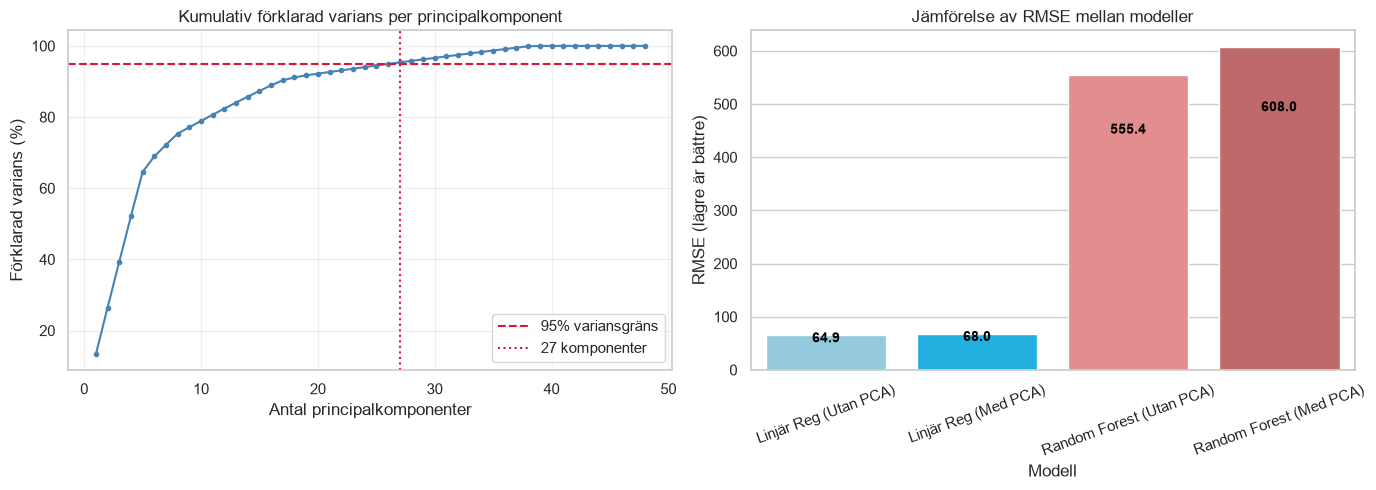

In [18]:
# 6. Sammanställning och visualisering av resultaten
results_df = pd.DataFrame({
    "Modell": ["Linjär Reg (Utan PCA)", "Linjär Reg (Med PCA)", "Random Forest (Utan PCA)", "Random Forest (Med PCA)"],
    "Antal variabler": [orig_dims, pca_dims, orig_dims, pca_dims],
    "RMSE (kr)": [rmse_lr_raw, rmse_lr_pca, rmse_rf_raw, rmse_rf_pca],
    "R² Score": [r2_lr_raw, r2_lr_pca, r2_rf_raw, r2_rf_pca]
})

print("=" * 70)
print("JÄMFÖRELSE AV MODELLER MED OCH UTAN PCA")
print("=" * 70)
display(results_df.round(4))

# Visualisering
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot A: Kumulativ förklarad varians
pca_full = PCA().fit(X_train_proc)
cumulative_var = np.cumsum(pca_full.explained_variance_ratio_) * 100

axes[0].plot(range(1, len(cumulative_var) + 1), cumulative_var, marker='o', markersize=3, color='steelblue')
axes[0].axhline(y=95, color='crimson', linestyle='--', label='95% variansgräns')
axes[0].axvline(x=pca_dims, color='crimson', linestyle=':', label=f'{pca_dims} komponenter')
axes[0].set_title("Kumulativ förklarad varians per principalkomponent")
axes[0].set_xlabel("Antal principalkomponenter")
axes[0].set_ylabel("Förklarad varians (%)")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Plot B: RMSE-jämförelse
sns.barplot(data=results_df, x="Modell", y="RMSE (kr)", palette=["skyblue", "deepskyblue", "lightcoral", "indianred"], ax=axes[1])
axes[1].set_title("Jämförelse av RMSE mellan modeller")
axes[1].set_ylabel("RMSE (lägre är bättre)")
axes[1].tick_params(axis='x', rotation=20)
for p in axes[1].patches:
    axes[1].annotate(f"{p.get_height():.1f}", (p.get_x() + p.get_width()/2., p.get_height() * 0.8),
                    ha='center', fontsize=10, fontweight='bold', color='black')

plt.tight_layout()
plt.show()


#### Slutsats och reflektion kring PCA-resultatet

1. **Effektiv dimensionsreducering:**  
   Genom att behålla 95% av variansen kunde vi reducera antalet variabler från **48 till 27 stycken** (en minskning med nästan 44%).
2. **Linjär regression hanterar PCA suveränt:**  
   Modellens $R^2$ förblir i princip identisk (**0.9995**) och RMSE ökar marginellt från 64.91 till 68.05 kr. För linjära modeller är PCA ett lysande verktyg för att banta dimensioner och eliminera multikollinearitet utan att tappa träffsäkerhet.
3. **Trädmodeller (Random Forest) föredrar rådata:**  
   För Random Forest ökade felet (RMSE gick från ca 555 till 608 kr). Beslutsträd fungerar bäst när de kan göra raka snitt på enskilda, ursprungliga variabler (t.ex. `Year > 2015`). När variablerna roteras och smetas ut över abstrakta principalkomponenter blir det svårare för träden att hitta enkla, skarpa trösklar.
